In [1]:
import numpy as np 
import pandas as pd
from src import utils, db, behavmatch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
from pathlib import Path
%matplotlib inline
%load_ext autoreload
%autoreload 2

First lets compute dprime vectors for all mice , in the case of the last training day, also using matched trials based on model probabilities

In [2]:
working_dbase = db.get_sessions().query("recording == True")
working_dbase.loc[:, "name_round"] = working_dbase["mname"] + "_"+ working_dbase["round_id"].astype(str)
sessions = working_dbase["session"].unique()
areas = ['V1', 'medial', 'lateral', 'anterior']
celltype = ['Pyr', 'Int'] 
nmice = working_dbase["name_round"].nunique()
nareas = len(areas)
ncelltypes = len(celltype)
n_sessions = len(sessions)

In [5]:
def dprime_cell(response, condition1, condition2, discrimination_region=(0,100), subpop=None):
    """
    Compute the d-prime for a single cell.
    """
    response = response[:,:,discrimination_region[0]:discrimination_region[1]].mean(2)
    r1 = response[:, condition1]
    r2 = response[:, condition2]
    if subpop is not None:
        r1 = r1[subpop]
        r2 = r2[subpop]
    # collect means and stds
    mu1 = r1.mean(1)
    mu2 = r2.mean(1)
    std1 = r1.std(1) + np.finfo(np.float64).tiny
    std2 = r2.std(1) + np.finfo(np.float64).tiny
    #compute the train dprime
    dp = 2 * ((mu1 - mu2) / (std1 + std2))
    return dp

In [9]:
sessions[2:]

array(['last training', 'all rewarded after'], dtype=object)

In [10]:
cbin = 3
obj_path = Path(r"D:\mouseobj")
for iss, sess in enumerate(sessions[2:]):
    d = working_dbase.query(f"session == '{sess}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        save_pth = obj_path.joinpath(name,datexp,blk)
        dp_prot = dprime_cell(m.interp_spks, m.trial_dict["rewarded"], m.trial_dict["non rewarded"], discrimination_region=(0,100))
        dp_rest = dprime_cell(m.interp_spks, m.trial_dict["rewarded test"], m.trial_dict["non rewarded test"], discrimination_region=(0,100))
        np.save(save_pth.joinpath("dp_prot_nosplit.npy"), dp_prot)
        np.save(save_pth.joinpath("dp_rest_nosplit.npy"), dp_rest)
        if sess == "last training":
            protA, protB, restA, restB = m.trial_dict["rewarded"], m.trial_dict["non rewarded"], m.trial_dict["rewarded test"], m.trial_dict["non rewarded test"]
            probs = np.load(save_pth.joinpath("probs.npy"), allow_pickle=True)
            prot_matched_trials = behavmatch.match_trials_by_prob_bins(probs, cbin, protA, protB, bins=np.linspace(0, 1, 11), random_state=0)
            rest_matched_trials = behavmatch.match_trials_by_prob_bins(probs, cbin, restA, restB, bins=np.linspace(0, 1, 11), random_state=0)
            m_rew = np.concatenate(prot_matched_trials[:,0]).astype(int)
            m_nrew = np.concatenate(prot_matched_trials[:,1]).astype(int)
            m_rew_test = np.concatenate(rest_matched_trials[:,0]).astype(int)
            m_nrew_test = np.concatenate(rest_matched_trials[:,1]).astype(int)
            dp_prot_matched = dprime_cell(m.interp_spks, m_rew, m_nrew, discrimination_region=(0,100))
            dp_rest_matched = dprime_cell(m.interp_spks, m_rew_test, m_nrew_test, discrimination_region=(0,100))
            np.save(save_pth.joinpath("dp_prot_nosplit_matched.npy"), dp_prot_matched)
            np.save(save_pth.joinpath("dp_rest_nosplit_matched.npy"), dp_rest_matched)
    clear_output(wait=True)

Processing: all rewarded after
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_01\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_15\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG14\20

In [76]:

def linear_func(p, x):
    """Linear function: y = p[0] * x + p[1]"""
    return p[0] * x + p[1]


def fit_TLS(x, y):
    from scipy.odr import ODR, Model, RealData
    linear_model = Model(linear_func)
    data = RealData(x, y)
    odr = ODR(data, linear_model, beta0=[0.5, 0.0])
    output = odr.run()
    return output


Text(0.5, 0.98, 'VGa9 all rewarded after')

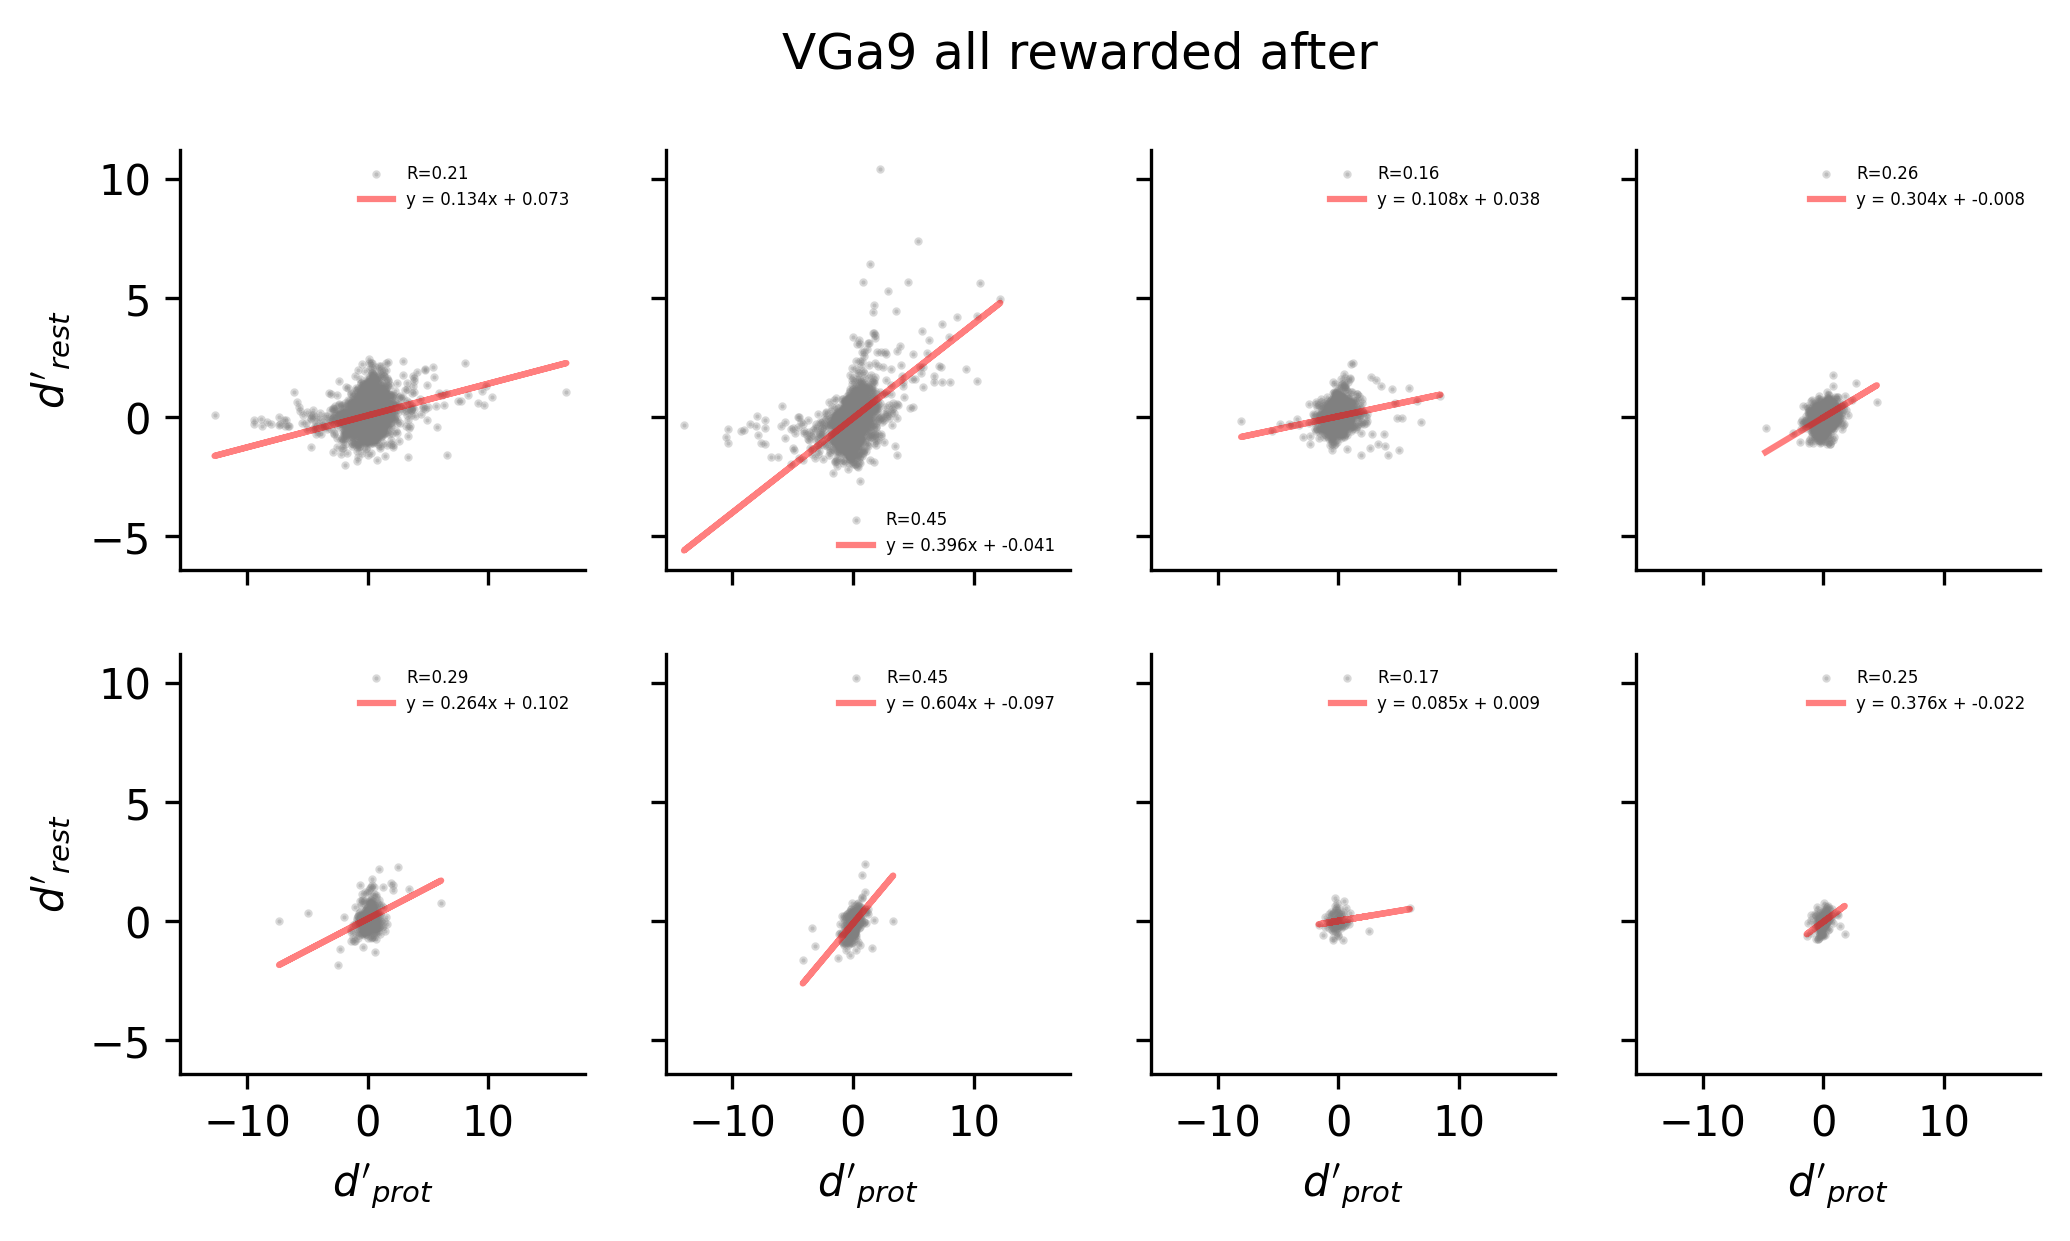

In [56]:
rows= []
fig, ax = plt.subplots(2,4, figsize=(8, 4), dpi=300, sharex=True, sharey=True)
for ic, cell in enumerate(celltype):
    sel_type = np.logical_not(m.isred[:, 0]).astype(bool) if cell == 'Pyr' else m.isred[:, 0].astype(bool)
    for ias, area in enumerate(areas):
        ia = utils.get_region_idx(m.iarea, area)
        selection = ia * sel_type
        dp_prot_sel = dp_prot[selection]
        dp_rest_sel = dp_rest[selection]
        corr = np.corrcoef(dp_prot_sel, dp_rest_sel)[0,1]
        reg_output = fit_TLS(dp_prot_sel, dp_rest_sel)
        slope = reg_output.beta[0]
        intercept = reg_output.beta[1]
        ax[ic, ias].scatter(dp_prot_sel, dp_rest_sel, rasterized=True, alpha=0.3, s=1, c='gray', label=f'R={corr:.2f}')
        ax[ic, ias].plot(dp_prot_sel, linear_func(reg_output.beta, dp_prot_sel), 'r-', alpha=0.5, label=f'y = {slope:.3f}x + {intercept:.3f}')
        ax[ic, ias].legend(fontsize=4, frameon=False)
        rows.append({'name': m.name, 'datexp': m.datexp, 'blk': m.blk, 'celltype': cell, 'area': area, 'corr': corr, 'slope': slope, 'intercept': intercept})
        if ic == ncelltypes - 1:
            ax[ic, ias].set_xlabel('$d\'_{prot}$')
        if ias == 0:
            ax[ic, ias].set_ylabel('$d\'_{rest}$')
sns.despine()
fig.suptitle(f"{m.name} {sess}")

over mice:

In [58]:
obj_path = Path(r"D:\mouseobj")
for iss, sess in enumerate(sessions):
    d = working_dbase.query(f"session == '{sess}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        save_pth = obj_path.joinpath(name,datexp,blk)
        rows= []
        dp_prot = np.load(save_pth.joinpath("dp_prot_nosplit.npy"))
        dp_rest = np.load(save_pth.joinpath("dp_rest_nosplit.npy"))
        fig, ax = plt.subplots(2,4, figsize=(8, 4), dpi=300, sharex=True, sharey=True)
        for ic, cell in enumerate(celltype):
            sel_type = np.logical_not(m.isred[:, 0]).astype(bool) if cell == 'Pyr' else m.isred[:, 0].astype(bool)
            for ias, area in enumerate(areas):
                ia = utils.get_region_idx(m.iarea, area)
                selection = ia * sel_type
                dp_prot_sel = dp_prot[selection]
                dp_rest_sel = dp_rest[selection]
                corr = np.corrcoef(dp_prot_sel, dp_rest_sel)[0,1]
                reg_output = fit_TLS(dp_prot_sel, dp_rest_sel)
                slope = reg_output.beta[0]
                intercept = reg_output.beta[1]
                ax[ic, ias].scatter(dp_prot_sel, dp_rest_sel, rasterized=True, alpha=0.3, s=1, c='gray', label=f'R={corr:.2f}')
                ax[ic, ias].plot(dp_prot_sel, linear_func(reg_output.beta, dp_prot_sel), 'r-', alpha=0.5, label=f'y = {slope:.3f}x + {intercept:.3f}')
                ax[ic, ias].legend(fontsize=4, frameon=False)
                rows.append({'name': name, 'datexp': datexp, 'blk': blk, 'session': sess, 'celltype': cell, 'area': area, 'corr': corr, 'slope': slope, 'intercept': intercept})
                if ic == ncelltypes - 1:
                    ax[ic, ias].set_xlabel('$d\'_{prot}$')
                if ias == 0:
                    ax[ic, ias].set_ylabel('$d\'_{rest}$')
        sns.despine()
        fig.suptitle(f"{name} {sess}")
        plt.savefig(save_pth.joinpath("dp_analysis.png"), dpi=300, bbox_inches='tight')
        plt.close()
        dp_analysis = pd.DataFrame(rows)
        dp_analysis.to_csv(save_pth.joinpath("dp_analysis.csv"), index=False)
        if sess == "last training":
            rows = []
            dp_prot = np.load(save_pth.joinpath("dp_prot_nosplit_matched.npy"))
            dp_rest = np.load(save_pth.joinpath("dp_rest_nosplit_matched.npy"))
            fig, ax = plt.subplots(2,4, figsize=(8, 4), dpi=300, sharex=True, sharey=True)
            for ic, cell in enumerate(celltype):
                sel_type = np.logical_not(m.isred[:, 0]).astype(bool) if cell == 'Pyr' else m.isred[:, 0].astype(bool)
                for ias, area in enumerate(areas):
                    ia = utils.get_region_idx(m.iarea, area)
                    selection = ia * sel_type
                    dp_prot_sel = dp_prot[selection]
                    dp_rest_sel = dp_rest[selection]
                    corr = np.corrcoef(dp_prot_sel, dp_rest_sel)[0,1]
                    reg_output = fit_TLS(dp_prot_sel, dp_rest_sel)
                    slope = reg_output.beta[0]
                    intercept = reg_output.beta[1]
                    ax[ic, ias].scatter(dp_prot_sel, dp_rest_sel, rasterized=True, alpha=0.3, s=1, c='gray', label=f'R={corr:.2f}')
                    ax[ic, ias].plot(dp_prot_sel, linear_func(reg_output.beta, dp_prot_sel), 'r-', alpha=0.5, label=f'y = {slope:.3f}x + {intercept:.3f}')
                    ax[ic, ias].legend(fontsize=4, frameon=False)
                    rows.append({'name': name, 'datexp': datexp, 'blk': blk, 'session': 'last training (matched)', 'celltype': cell, 'area': area, 'corr': corr, 'slope': slope, 'intercept': intercept})
                    if ic == ncelltypes - 1:
                        ax[ic, ias].set_xlabel('$d\'_{prot}$')
                    if ias == 0:
                        ax[ic, ias].set_ylabel('$d\'_{rest}$')
            sns.despine()
            fig.suptitle(f"{name} last training (matched)")
            plt.savefig(save_pth.joinpath("dp_analysis_matched.png"), dpi=300, bbox_inches='tight')
            plt.close()
            dp_analysis = pd.DataFrame(rows)
            dp_analysis.to_csv(save_pth.joinpath("dp_analysis_matched.csv"), index=False)
        clear_output(wait=True)

Checking if model object exists ...
Loading mouse object from D:\mouseobj\VGa9\2025_11_21\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])


In [60]:
working_dbase = db.get_sessions().query("recording == True")

In [62]:
obj_path = Path(r"D:\mouseobj")
all_dp_df = pd.DataFrame()
for i, (_, row) in enumerate(working_dbase.iterrows()):
    name, datexp, blk = row["mname"], row["datexp"], row["blk"]
    save_pth = obj_path.joinpath(name,datexp,blk)
    df = pd.read_csv(save_pth.joinpath("dp_analysis.csv"))
    all_dp_df = pd.concat([all_dp_df, df], ignore_index=True)
    if row["session"] == "last training":
        df_matched = pd.read_csv(save_pth.joinpath("dp_analysis_matched.csv"))
        all_dp_df = pd.concat([all_dp_df, df_matched], ignore_index=True)
all_dp_df
    

,name,datexp,blk,session,celltype,area,corr,slope,intercept
0,VG11,2024_10_15,4,all rewarded before,Pyr,V1,0.152597,0.077114,-0.047166
1,VG11,2024_10_15,4,all rewarded before,Pyr,medial,0.267474,0.164568,-0.026834
2,VG11,2024_10_15,4,all rewarded before,Pyr,lateral,0.130629,0.074992,-0.027670
3,VG11,2024_10_15,4,all rewarded before,Pyr,anterior,0.184761,0.158427,-0.022228
4,VG11,2024_10_15,4,all rewarded before,Int,V1,0.035634,0.015209,-0.084421
...,...,...,...,...,...,...,...,...,...
387,VGa9,2025_11_21,2,all rewarded after,Pyr,anterior,0.263224,0.304388,-0.008175
388,VGa9,2025_11_21,2,all rewarded after,Int,V1,0.291629,0.263701,0.102266
389,VGa9,2025_11_21,2,all rewarded after,Int,medial,0.449389,0.604168,-0.096673
390,VGa9,2025_11_21,2,all rewarded after,Int,lateral,0.169449,0.084574,0.009093


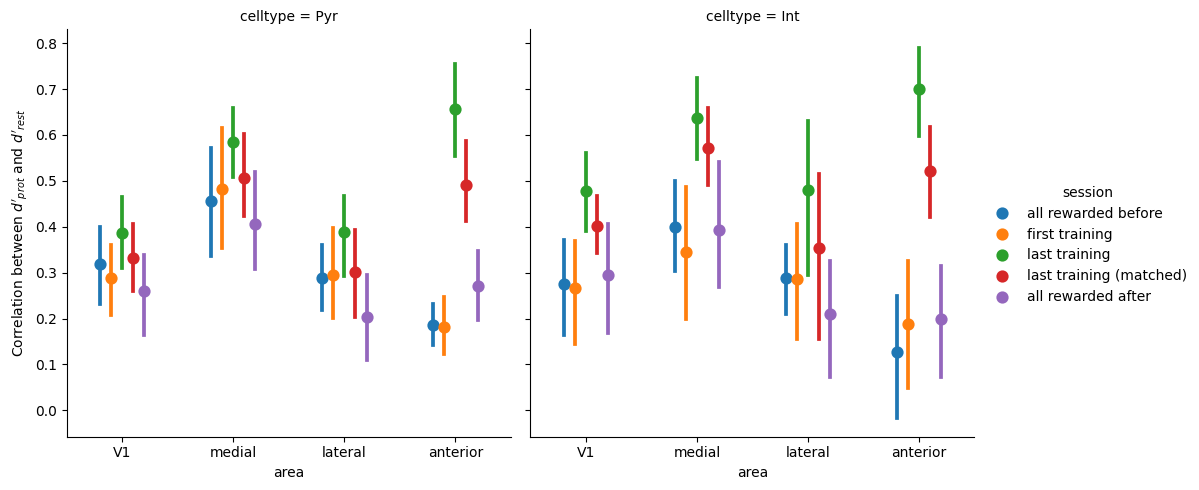

In [70]:
g = sns.catplot(data=all_dp_df, x='area', y='corr', col='celltype', hue='session', kind='point', width=4, aspect=1, dodge=.4, linestyle='none')
g.set_ylabels('Correlation between $d\'_{prot}$ and $d\'_{rest}$')

VG21 all before failed to fit the TLS line , since correlation between d' is 0, infinite lines are possible.
changing to NAN that value

In [ ]:
all_dp_df.query("area == 'anterior' & celltype == 'Int' & session == 'all rewarded before'")


,name,datexp,blk,session,celltype,area,corr,slope,intercept
7,VG11,2024_10_15,4,all rewarded before,Int,anterior,0.164855,0.105306,-0.028812
47,VG11,2024_11_04,2,all rewarded before,Int,anterior,0.260520,0.520082,-0.083216
87,VG14,2024_10_15,2,all rewarded before,Int,anterior,0.311664,0.242342,-0.079774
127,VG15,2024_10_15,3,all rewarded before,Int,anterior,-0.110777,-0.055997,-0.029756
167,VG21,2025_06_24,3,all rewarded before,Int,anterior,0.390375,0.688338,0.012952
207,VG21,2025_07_21,2,all rewarded before,Int,anterior,-0.003425,83.064381,-3.432779
247,VG24,2025_06_25,2,all rewarded before,Int,anterior,-0.347274,-0.917912,0.126886
287,VG33,2025_09_30,2,all rewarded before,Int,anterior,0.194916,0.602478,-0.090763
327,VG34,2025_09_30,3,all rewarded before,Int,anterior,0.241178,0.887794,-0.001903
359,VGa9,2025_11_06,4,all rewarded before,Int,anterior,0.176274,0.147025,-0.054246


In [83]:
all_dp_df.loc[207, ['slope', 'intercept']] = [np.nan, np.nan]
all_dp_df.query("area == 'anterior' & celltype == 'Int' & session == 'all rewarded before'")

,name,datexp,blk,session,celltype,area,corr,slope,intercept
7,VG11,2024_10_15,4,all rewarded before,Int,anterior,0.164855,0.105306,-0.028812
47,VG11,2024_11_04,2,all rewarded before,Int,anterior,0.260520,0.520082,-0.083216
87,VG14,2024_10_15,2,all rewarded before,Int,anterior,0.311664,0.242342,-0.079774
127,VG15,2024_10_15,3,all rewarded before,Int,anterior,-0.110777,-0.055997,-0.029756
167,VG21,2025_06_24,3,all rewarded before,Int,anterior,0.390375,0.688338,0.012952
207,VG21,2025_07_21,2,all rewarded before,Int,anterior,-0.003425,NaN,NaN
247,VG24,2025_06_25,2,all rewarded before,Int,anterior,-0.347274,-0.917912,0.126886
287,VG33,2025_09_30,2,all rewarded before,Int,anterior,0.194916,0.602478,-0.090763
327,VG34,2025_09_30,3,all rewarded before,Int,anterior,0.241178,0.887794,-0.001903
359,VGa9,2025_11_06,4,all rewarded before,Int,anterior,0.176274,0.147025,-0.054246


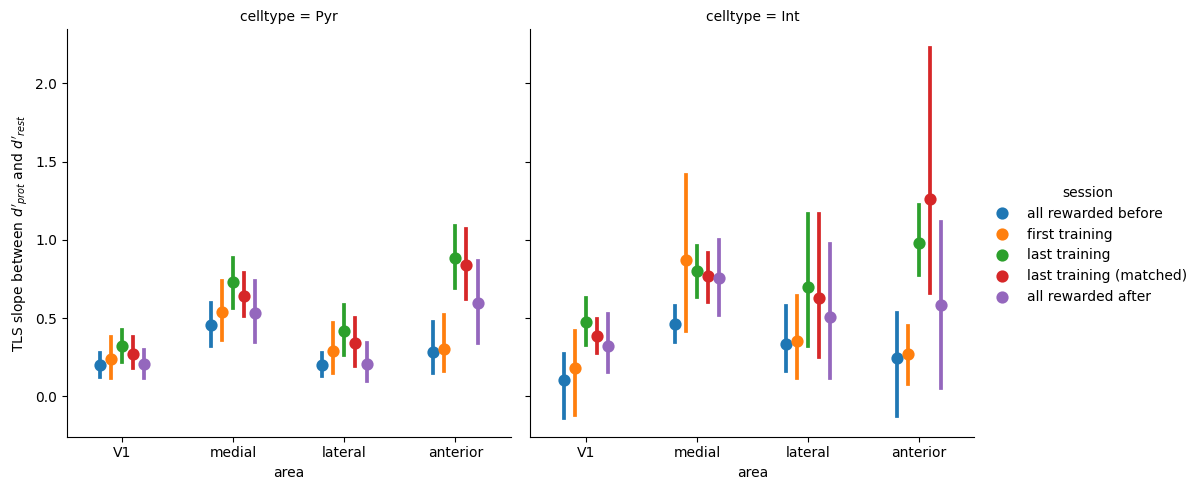

In [84]:
g = sns.catplot(data=all_dp_df, x='area', y='slope', col='celltype', hue='session', kind='point', width=4, aspect=1, dodge=.4, linestyle='none')
g.set_ylabels('TLS slope between $d\'_{prot}$ and $d\'_{rest}$')

So the correlation between d'prot and d'rest answers the questions: are the same neurons encoding the prototypes also encoding the rest of the exemplars? 

Based on the results seems that for the excitatory cells:

- Anterior area: yes, the same neurons encode both prototype and rest exemplars, but it catchs up the medial area, having similar correlation.

- Medial area: yes, the same neurons encode both prototype and rest exemplars, since the beggining of training.

For the interneurons:

Both anterior and medial areas show high correlation between d'prot and d'rest, meaning that the same interneurons encode both prototype and rest exemplars, after training.

## What we are missing?

To me we still need to find the best way to measure such quantity (invariance) and even if the invariance increases, or we are successful at measuring it, would be ideal to see if the invariance change is due to a mere increase in signal or an actual collapse to classes.

To measure invariance I would like to try the following:

First we define the coding direction axis:

$w = \frac{E_{\text{rewarded}} - E_{\text{nonrewarded}}}{\|E_{\text{rewarded}} - E_{\text{nonrewarded}}\|} $

then we project the non prototype exemplars onto that axis:

$P_{R_{rest}} = E_{R_{rest}} \cdot w $

$P_{NR_{rest}} = E_{NR_{rest}} \cdot w $

and calculate d' between those two distributions of projections:

$inv = 2 * \frac{\mu_{P_{R_{rest}}} - \mu_{P_{NR_{rest}}}}{(\sigma_{P_{R_{rest}}} + \sigma_{P_{NR_{rest}}})} $

**This way we are measuring how well the non prototype exemplars are separated along the coding axis defined by the prototypes.**

In [4]:
working_dbase = db.get_sessions().query("recording == True")
working_dbase

,mname,datexp,blk,session,round_id,recording,obj
0,VG11,2024_10_15,4,all rewarded before,1,True,old
1,VG11,2024_10_16,2,first training,1,True,old
2,VG11,2024_10_31,2,last training,1,True,old
3,VG11,2024_11_01,2,all rewarded after,1,True,old
4,VG11,2024_11_04,2,all rewarded before,2,True,old
5,VG11,2024_11_05,3,first training,2,True,old
6,VG11,2024_11_14,2,last training,2,True,old
7,VG11,2024_11_15,2,all rewarded after,2,True,old
8,VG14,2024_10_15,2,all rewarded before,1,True,old
9,VG14,2024_10_16,2,first training,1,True,old


In [5]:
name, date, blk = working_dbase.loc[38,'mname'], working_dbase.loc[38,'datexp'], working_dbase.loc[38,'blk']
m = utils.load_mouse(name, date, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")

Checking if model object exists ...
Loading mouse object from D:\mouseobj\VGa9\2025_11_20\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])


In [132]:
def get_projections(m, selection, trial_dict):
    all_means = m.interp_spks[:,:,:100].mean(2)
    all_means = all_means[selection,:]
    all_means = all_means.T
    Rprot, NRprot, Rrest, NRrest = trial_dict["rewarded"], trial_dict["non rewarded"], trial_dict["rewarded test"], trial_dict["non rewarded test"]
    Eprot = all_means[Rprot[::2]].mean(0)
    ENRprot = all_means[NRprot[::2]].mean(0)
    Erest = all_means[Rrest]
    ENRrest = all_means[NRrest]
    Eprot_test = all_means[Rprot[1::2]].mean(0)
    ENRprot_test = all_means[NRprot[1::2]].mean(0)
    w_proto = Eprot_test - ENRprot_test
    w_nonproto = np.mean(Erest, axis=0) - np.mean(ENRrest, axis=0)
    cos_angle = np.dot(w_proto, w_nonproto) / (np.linalg.norm(w_proto.flatten()) * np.linalg.norm(w_nonproto.flatten()) + 1e-6)
    cd = Eprot - ENRprot
    w = cd / (np.linalg.norm(cd) + np.finfo(np.float64).tiny)

    proj_R_prot = np.dot(all_means[Rprot[1::2]], w)
    proj_NR_prot = np.dot(all_means[NRprot[1::2]], w)
    proj_R_rest = np.dot(all_means[Rrest], w)
    proj_NR_rest = np.dot(all_means[NRrest], w)
    return cos_angle, proj_R_prot, proj_NR_prot, proj_R_rest, proj_NR_rest

def ei_alignment(m, area, trial_dict, correct_incorrect=False):
    from scipy.stats import pearsonr
    all_means = m.interp_spks[:,:,:100].mean(2)
    all_means = all_means[area,:]
    all_means = all_means.T  
    is_exc = np.logical_not(m.isred[area, 0]).astype(bool)
    is_inh = m.isred[area, 0].astype(bool)
    means_exc = all_means[:, is_exc]  # Excitatory neurons
    means_inh = all_means[:, is_inh]  # Inhibitory neuron
    Rprot, NRprot, Rrest, NRrest = trial_dict["rewarded"], trial_dict["non rewarded"], trial_dict["rewarded test"], trial_dict["non rewarded test"]
    w_exc = means_exc[Rprot].mean(0) - means_exc[NRprot].mean(0)
    w_inh = means_inh[Rprot].mean(0) - means_inh[NRprot].mean(0)
    
    np_indices = np.concatenate([Rrest, NRrest])
    scores_exc = means_exc[np_indices] @ w_exc
    scores_inh = means_inh[np_indices] @ w_inh
    alignment_r, _ = pearsonr(scores_exc, scores_inh)

    if correct_incorrect:
        correct, incorrect = utils.build_correct_dicts(m)
        correct_protA = np.intersect1d(correct["rewarded"], Rprot)
        correct_protB = np.intersect1d(correct["non rewarded"], NRprot)
        w_exc = means_exc[correct_protA].mean(0) - means_exc[correct_protB].mean(0)
        w_inh = means_inh[correct_protA].mean(0) - means_inh[correct_protB].mean(0)
        np_indices_correct = np.concatenate([correct["rewarded test"], correct["non rewarded test"]])
        np_indices_incorrect = np.concatenate([incorrect["rewarded test"], incorrect["non rewarded test"]])
        scores_exc_correct = means_exc[np_indices_correct] @ w_exc
        scores_inh_correct = means_inh[np_indices_correct] @ w_inh
        alignment_r_correct, _ = pearsonr(scores_exc_correct, scores_inh_correct)
        scores_exc_incorrect = means_exc[np_indices_incorrect] @ w_exc
        scores_inh_incorrect = means_inh[np_indices_incorrect] @ w_inh
        alignment_r_incorrect, _ = pearsonr(scores_exc_incorrect, scores_inh_incorrect)
        return alignment_r, alignment_r_correct, alignment_r_incorrect
    
    return alignment_r

def participation_ratio(m, selection, trial_dict):
    from sklearn.decomposition import PCA
    all_means = m.interp_spks[:,:,:100].mean(2)
    all_means = all_means[selection,:]
    all_means = all_means.T
    Rprot, NRprot, Rrest, NRrest = trial_dict["rewarded"], trial_dict["non rewarded"], trial_dict["rewarded test"], trial_dict["non rewarded test"]
    all_nonproto = all_means[np.concatenate([Rrest, NRrest]), :]
    pca = PCA().fit(all_nonproto)
    lambda_vals = pca.explained_variance_
    pr = (np.sum(lambda_vals))**2 / np.sum(lambda_vals**2 + np.finfo(np.float64).tiny)
    return pr

import numpy as np
#import silluete_score


def calculate_manifold_compression(m, selection, trial_dict):
    """
    means_r: (trials, N_neurons)
    means_u: (trials, N_neurons)
    """
    all_means = m.interp_spks[:,:,:100].mean(2)
    all_means = all_means[selection,:]
    all_means = all_means.T
    Rprot, NRprot, Rrest, NRrest = trial_dict["rewarded"], trial_dict["non rewarded"], trial_dict["rewarded test"], trial_dict["non rewarded test"]
    # 1. Calculate Centroids
    centroid_r = np.mean(all_means[Rrest], axis=0)
    centroid_u = np.mean(all_means[NRrest], axis=0)
    
    # 2. Calculate average Radius (Internal Variance)
    radius_r = np.mean(np.linalg.norm(all_means[Rrest] - centroid_r, axis=1))
    radius_u = np.mean(np.linalg.norm(all_means[NRrest] - centroid_u, axis=1))
    
    # 3. Calculate Between-Category Distance
    separation_np = np.linalg.norm(centroid_r - centroid_u)
    centroid_r_prot = np.mean(all_means[Rprot], axis=0)
    centroid_u_prot = np.mean(all_means[NRprot], axis=0)
    separation_p = np.linalg.norm(centroid_r_prot - centroid_u_prot)
    
    return separation_p, separation_np, radius_r, radius_u

from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score

def compute_shattering_capacity(m, selection, trial_dict, n_shuffles=100):
    """
    means: array of shape (trials, N_neurons) 
    n_shuffles: number of random dichotomic labels to test
    """
    all_means = m.interp_spks[:,:,:100].mean(2)
    all_means = all_means[selection,:]
    all_means = all_means.T
    Rprot, NRprot, Rrest, NRrest = trial_dict["rewarded"], trial_dict["non rewarded"], trial_dict["rewarded test"], trial_dict["non rewarded test"]
    all_nonproto = all_means[np.concatenate([Rrest, NRrest]), :]
    shattering_scores = []
    
    # We use a Linear SVM with a fixed C to keep it comparable across areas
    model = LinearSVC(C=1.0, max_iter=1000)

    real_labels = np.array([1]*len(Rrest) + [0]*len(NRrest))
    scores_real = cross_val_score(model, all_nonproto, real_labels, cv=5)
    
    for i in range(n_shuffles):
        # 1. Generate random binary labels (50 zeros, 50 ones)
        
        random_labels = np.array([0]*len(NRrest) + [1]*len(Rrest))
        np.random.shuffle(random_labels)
        
        # 2. Measure how well the area can solve this random grouping
        # We use 3-fold cross-validation
        try:
            scores = cross_val_score(model, all_nonproto, random_labels, cv=3)
            shattering_scores.append(np.mean(scores))
        except:
            # Handle cases where SVM fails to converge
            continue
            
    return np.mean(scores_real), np.mean(shattering_scores)


Get the coding dir:

In [7]:
def dp_inv(r1, r2):
    mu1 = r1.mean()
    mu2 = r2.mean()
    std1 = r1.std() + np.finfo(np.float64).tiny
    std2 = r2.std() + np.finfo(np.float64).tiny
    #compute the train dprime
    dp = 2 * ((mu1 - mu2) / (std1 + std2))
    return dp

def get_matched_trials(m):
    object_path = Path(r"D:\mouseobj")
    cbin = 3 
    name, datexp, blk = m.name, m.datexp, m.blk
    save_pth = object_path.joinpath(name,datexp,blk)
    protA = m.trial_dict["rewarded"]
    protB = m.trial_dict["non rewarded"]
    restA = m.trial_dict["rewarded test"]
    restB =  m.trial_dict["non rewarded test"]
    probs = np.load(save_pth.joinpath("probs.npy"), allow_pickle=True)
    prot_matched_trials = behavmatch.match_trials_by_prob_bins(probs, cbin, protA, protB, bins=np.linspace(0, 1, 11), random_state=0)
    rest_matched_trials = behavmatch.match_trials_by_prob_bins(probs, cbin, restA, restB, bins=np.linspace(0, 1, 11), random_state=0)
    m_rew = np.concatenate(prot_matched_trials[:,0]).astype(int)
    m_nrew = np.concatenate(prot_matched_trials[:,1]).astype(int)
    m_rew_test = np.concatenate(rest_matched_trials[:,0]).astype(int)
    m_nrew_test = np.concatenate(rest_matched_trials[:,1]).astype(int)
    trial_dict_matched = {"rewarded": m_rew,
                        "non rewarded": m_nrew,
                        "rewarded test": m_rew_test,
                        "non rewarded test": m_nrew_test}
    return trial_dict_matched

In [ ]:
areas = ['V1', 'medial', 'lateral', 'anterior']
celltype = ['Pyr', 'Int']
invariances = np.empty((len(areas), len(celltype)))
pr = np.empty((len(areas), len(celltype)))
angles = np.empty((len(areas), len(celltype)))
matched_trial_dict = get_matched_trials(m)
ei_angles = np.empty((len(areas)))
separation = np.empty((len(areas), len(celltype)))
radius_r = np.empty((len(areas), len(celltype)))
radius_u = np.empty((len(areas), len(celltype)))
ei_correct = np.empty((len(areas)))
ei_incorrect = np.empty((len(areas)))
for iaa, area in enumerate(areas):
    ia = utils.get_region_idx(m.iarea, area)
    alignment = ei_alignment(m, ia, matched_trial_dict)
    ei_angles[iaa] = alignment
    for ic, cell in enumerate(celltype):
        sel_type = np.logical_not(m.isred[:, 0]).astype(bool) if cell == 'Pyr' else m.isred[:, 0].astype(bool)
        selection = ia * sel_type
        angle, proj_R_prot, proj_NR_prot, proj_R_rest, proj_NR_rest = get_projections(m, selection, matched_trial_dict)
        dp_prot = dp_inv(proj_R_prot, proj_NR_prot)
        dp_rest = dp_inv(proj_R_rest, proj_NR_rest)
        dp_inv_value = dp_rest / (dp_prot + 1e-6)
        invariances[iaa, ic] = dp_inv_value
        angles[iaa, ic] = angle

In [49]:
ei_angles

array([0.89208227, 0.95077105, 0.6928936 , 0.8780726 ])

In [53]:
invariances

array([[0.31016563, 0.34149219],
       [0.52935828, 0.61118092],
       [0.18730854, 0.15740834],
       [0.54146275, 0.85505871]])

In [54]:
angles

array([[0.18890827, 0.3205973 ],
       [0.41520546, 0.49558418],
       [0.18872869, 0.17744793],
       [0.32935554, 0.45591724]])

In [58]:
sessions_names = ['all rewarded before', 'first training', 'last training', 'last training (matched)' ,'all rewarded after']

In [59]:
rows = []
for iss, sess in enumerate(sessions_names):
    if sess == 'last training (matched)':
        session = 'last training'
    else:
        session = sess
    d = working_dbase.query(f"session == '{session}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        if sess == 'last training (matched)':
            t_dict = get_matched_trials(m)
        else:
            t_dict = m.trial_dict
        for iaa, area in enumerate(areas):
            ia = utils.get_region_idx(m.iarea, area)
            alignment = ei_alignment(m, ia, t_dict)
            for ic, cell in enumerate(celltype):
                sel_type = np.logical_not(m.isred[:, 0]).astype(bool) if cell == 'Pyr' else m.isred[:, 0].astype(bool)
                selection = ia * sel_type
                angle, proj_R_prot, proj_NR_prot, proj_R_rest, proj_NR_rest = get_projections(m, selection, t_dict)
                dp_prot = dp_inv(proj_R_prot, proj_NR_prot)
                dp_rest = dp_inv(proj_R_rest, proj_NR_rest)
                dp_inv_value = dp_rest / (dp_prot + 1e-6)
                rows.append({'name': name, 'datexp': datexp, 'blk': blk, 
                             'session': sess, 'celltype': cell, 'area': area, 
                             'invariance': dp_inv_value, 'angle': angle, 'ei_angle': alignment})
    clear_output(wait=True)
dp_invariance_df = pd.DataFrame(rows)

Processing: all rewarded after
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_01\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_15\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG14\20

In [115]:
dp_invariance_df.to_csv(r"D:\mouseobj\overall\dp_proj_invariance_analysis.csv", index=False)

In [93]:
dp_invariance_df = pd.read_csv(r"D:\mouseobj\overall\dp_proj_invariance_analysis.csv")

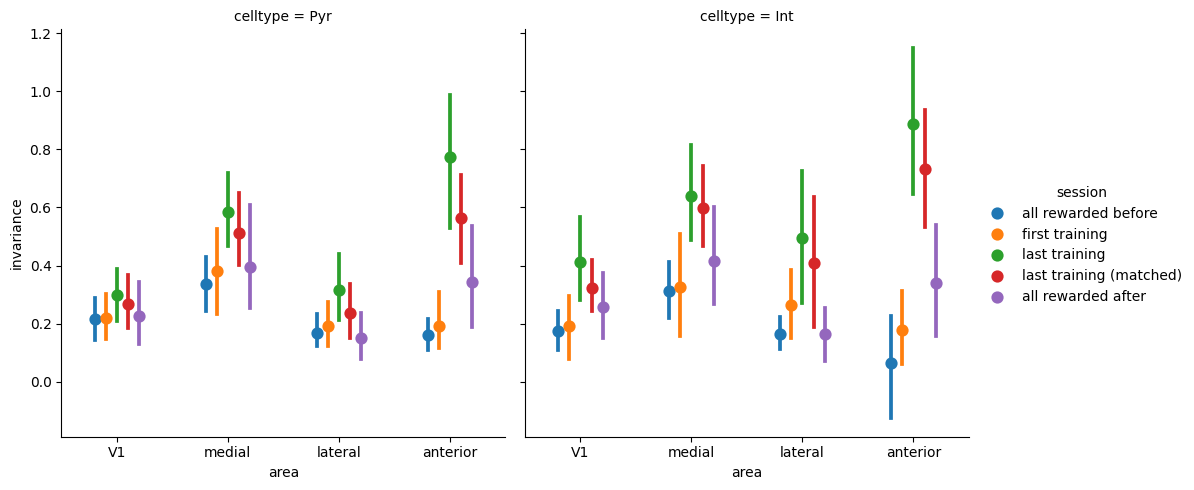

In [94]:
sns.catplot(data=dp_invariance_df, x='area', y='invariance', col='celltype', hue='session', kind='point', width=4, aspect=1, dodge=.4, linestyle='none')

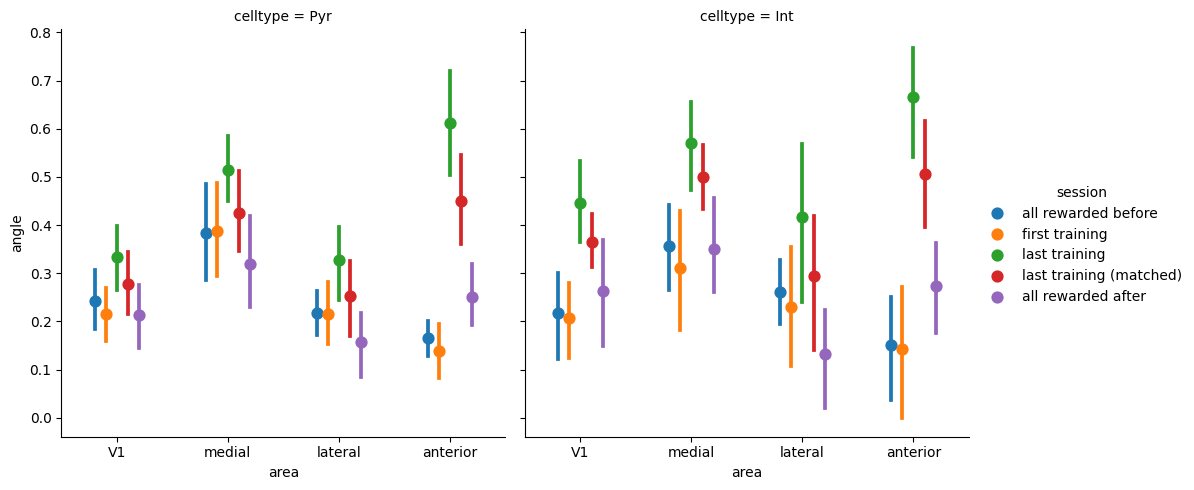

In [61]:
sns.catplot(data=dp_invariance_df, x='area', y='angle', col='celltype', hue='session', kind='point', width=4, aspect=1, dodge=.4, linestyle='none')

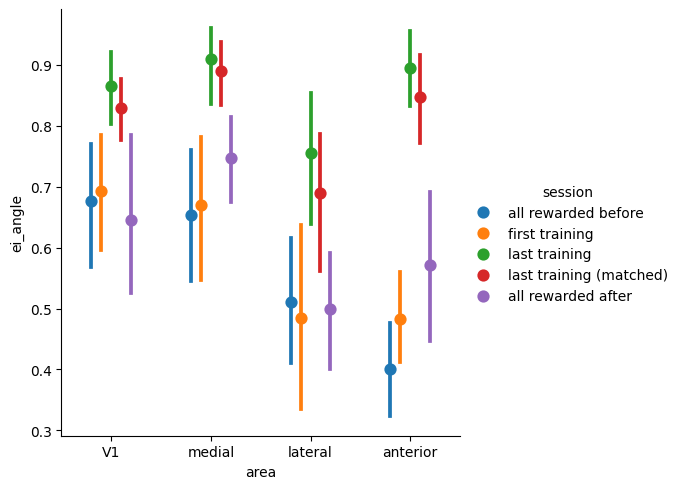

In [ ]:
sns.catplot(data=dp_invariance_df.query("celltype == 'Pyr'"), x='area', y='ei_angle', hue='session', kind='point', width=4, aspect=1, dodge=.4, linestyle='none')
plt.ylabel('EI alignment (r)')

In [87]:
dp_invariance_df.query("celltype == 'Pyr'")

,name,datexp,blk,session,celltype,area,invariance,angle,ei_angle
0,VG11,2024_10_15,4,all rewarded before,Pyr,V1,0.092217,0.113661,0.327213
2,VG11,2024_10_15,4,all rewarded before,Pyr,medial,0.205363,0.247266,0.506519
4,VG11,2024_10_15,4,all rewarded before,Pyr,lateral,0.071679,0.104142,0.328305
6,VG11,2024_10_15,4,all rewarded before,Pyr,anterior,0.103274,0.146981,0.568248
8,VG11,2024_11_04,2,all rewarded before,Pyr,V1,0.189265,0.260263,0.590161
...,...,...,...,...,...,...,...,...,...
382,VG33,2025_10_10,2,all rewarded after,Pyr,anterior,0.320438,0.228568,0.472699
384,VGa9,2025_11_21,2,all rewarded after,Pyr,V1,0.178120,0.190463,0.859988
386,VGa9,2025_11_21,2,all rewarded after,Pyr,medial,0.332995,0.369244,0.856297
388,VGa9,2025_11_21,2,all rewarded after,Pyr,lateral,0.069900,0.143271,0.496681


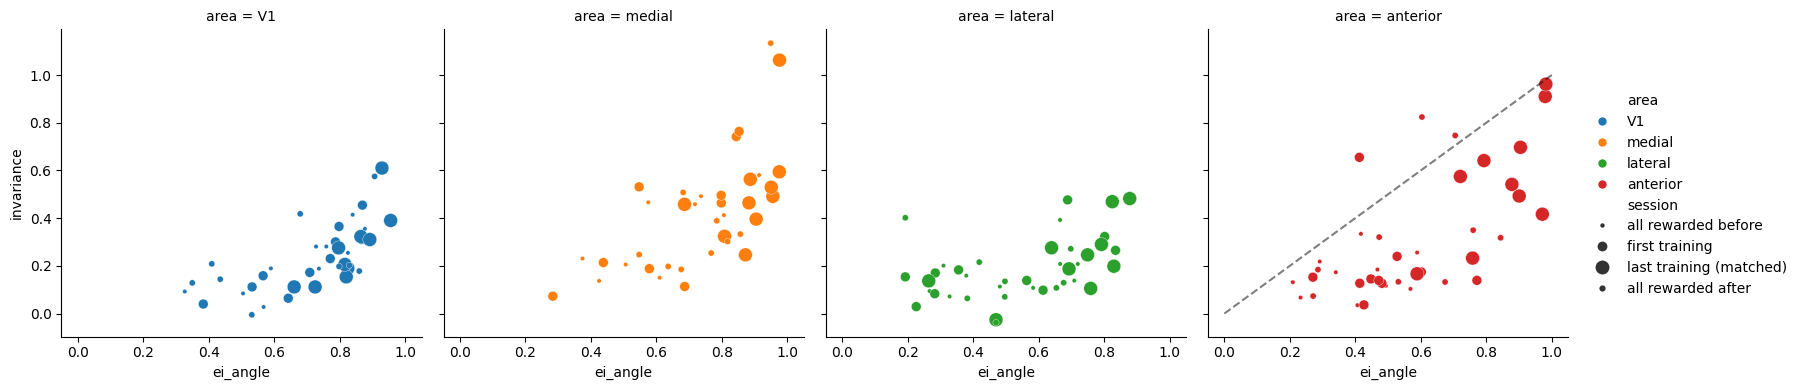

In [101]:
sns.relplot(data=dp_invariance_df.query("celltype == 'Pyr' & session not in ['last training']"), x='ei_angle', y='invariance', hue='area', size='session', kind='scatter', col="area", sizes=[10, 50, 100, 20], height=4, aspect=1)
#45 degrees line
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)

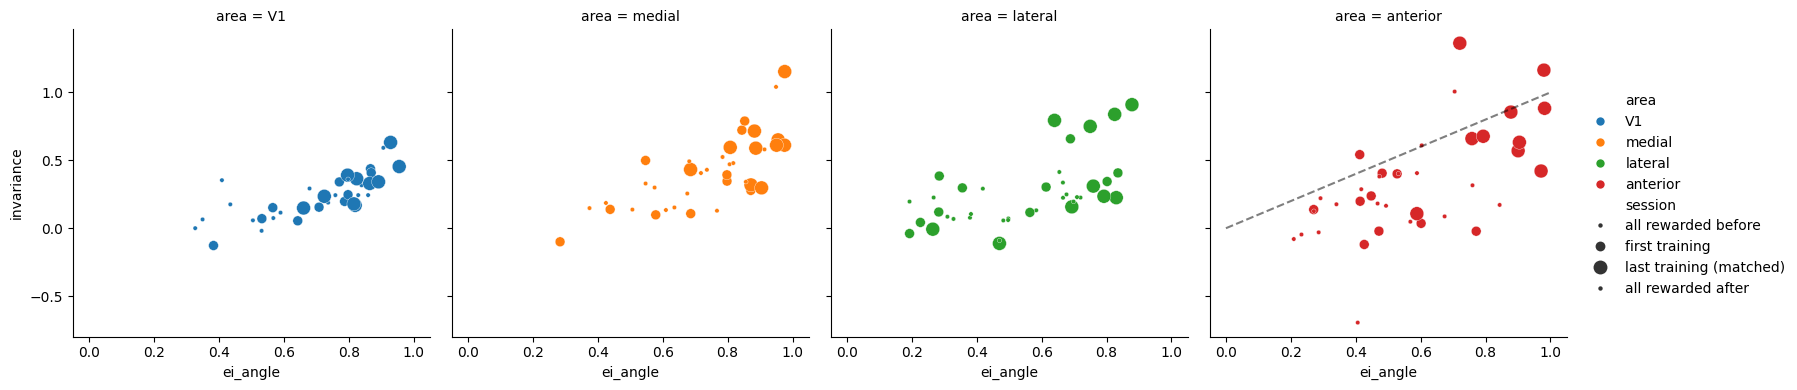

In [98]:
sns.relplot(data=dp_invariance_df.query("celltype == 'Int' & session not in ['last training']"), x='ei_angle', y='invariance', hue='area', size='session', kind='scatter', col="area", sizes=[10, 50, 100, 10], height=4, aspect=1)
#45 degrees line
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)

In [112]:
from scipy.stats import pearsonr

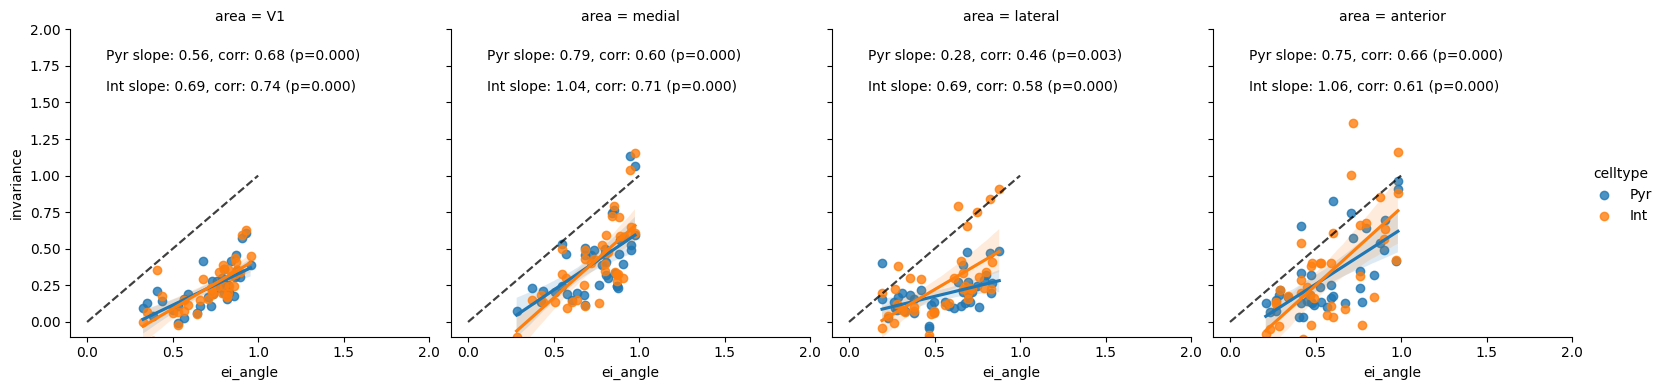

In [114]:
sns.lmplot(data=dp_invariance_df.query("session not in ['last training']"), 
           x='ei_angle', y='invariance', hue='celltype', col="area", robust=False, height=4, aspect=1)
#add the reg coef and the corr coef with significance
for ax, area in zip(plt.gcf().axes, areas):
    sub_df = dp_invariance_df.query(f"area == '{area}' & session not in ['last training']")
    for cell in celltype:
        cell_df = sub_df.query(f"celltype == '{cell}'")
        slope, intercept = np.polyfit(cell_df['ei_angle'], cell_df['invariance'], 1)
        corr, pvalue = pearsonr(cell_df['ei_angle'], cell_df['invariance'])
        #pvalue
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        ax.text(0.1, 0.9 - 0.1*celltype.index(cell), f"{cell} slope: {slope:.2f}, corr: {corr:.2f} (p={pvalue:.3f})", transform=ax.transAxes)
        ax.set_ylim(-.1,2)
        ax.set_xlim(-.1,2)

In [95]:
def get_invariance(df: pd.DataFrame, area: str, celltype: str, session: str) -> tuple[np.ndarray, np.ndarray]:
    a = df.query(f"session == '{session}'")
    b = a.query(f"area == '{area}' & celltype == '{celltype}'")
    invariance_values= b['invariance'].values
    return invariance_values

def get_feature_values(df: pd.DataFrame, area: str, celltype: str, session: str, feature: str) -> np.ndarray:
    a = df.query(f"session == '{session}'")
    b = a.query(f"area == '{area}' & celltype == '{celltype}'")
    feature_values= b[feature].values
    return feature_values

In [96]:
sessions = ['first training', 'last training', 'last training (matched)']
areas = ['V1', 'medial', 'lateral', 'anterior']
celltype = ['Pyr', 'Int']
nmice = 10
angles = {}
for sess in sessions: 
    angle = np.empty((nmice, len(areas), len(celltype)))
    for ia, area in enumerate(areas):
        for ic, ctype in enumerate(celltype):
            inv = get_feature_values(dp_invariance_df, area, ctype, sess, 'angle')
            #store values
            angle[:,ia,ic] = inv
    angles[sess] = angle

In [97]:
sessions = ['first training', 'last training', 'last training (matched)']
areas = ['V1', 'medial', 'lateral', 'anterior']
celltype = ['Pyr', 'Int']
nmice = 10
invariances = {}
for sess in sessions: 
    inv_index = np.empty((nmice, len(areas), len(celltype)))
    for ia, area in enumerate(areas):
        for ic, ctype in enumerate(celltype):
            inv = get_invariance(dp_invariance_df, area, ctype, sess)
            #store values
            inv_index[:,ia,ic] = inv
    invariances[sess] = inv_index

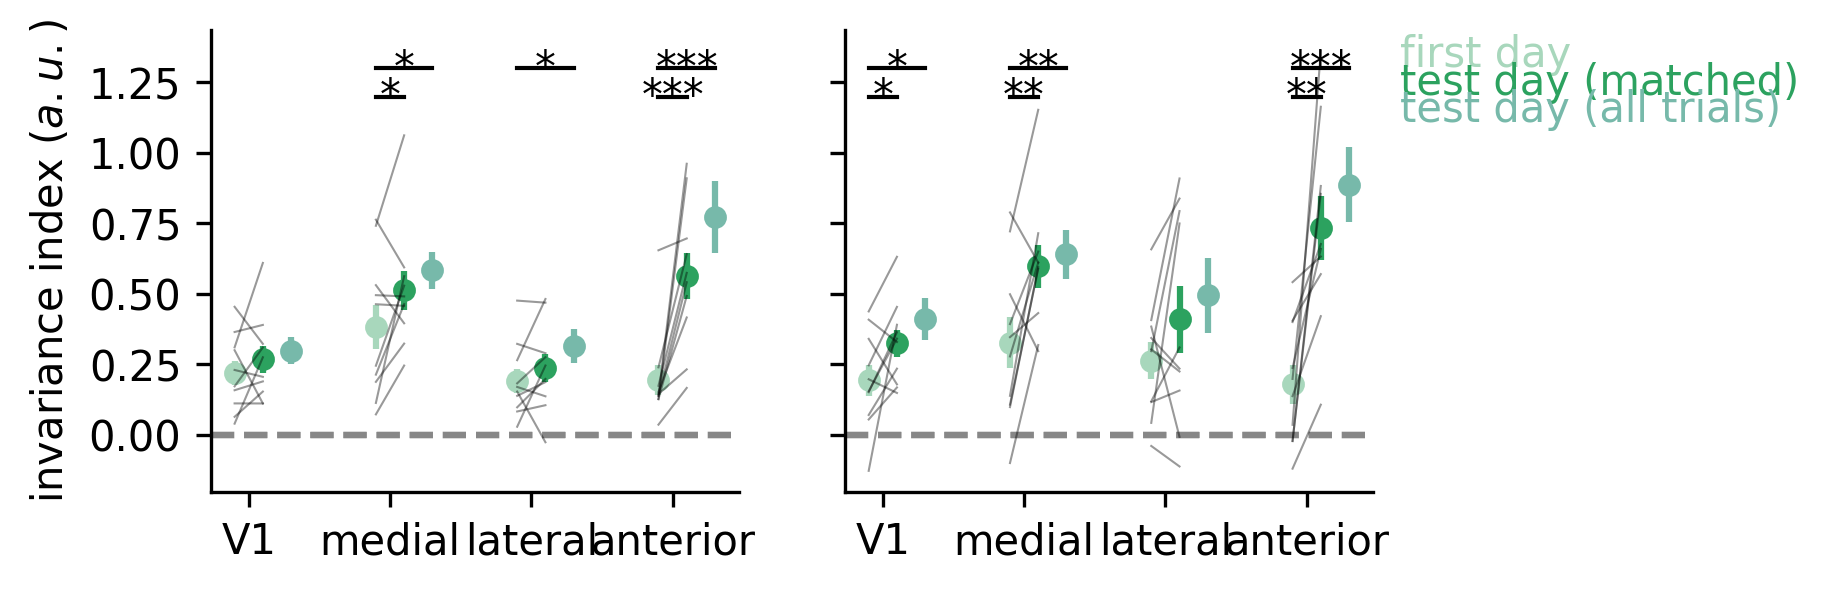

In [98]:
from src import fig1
gis_first = invariances['first training']
gis_last = invariances['last training']
gis_last_m = invariances['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=1.2, sig_line_control=1.3)
sns.despine()

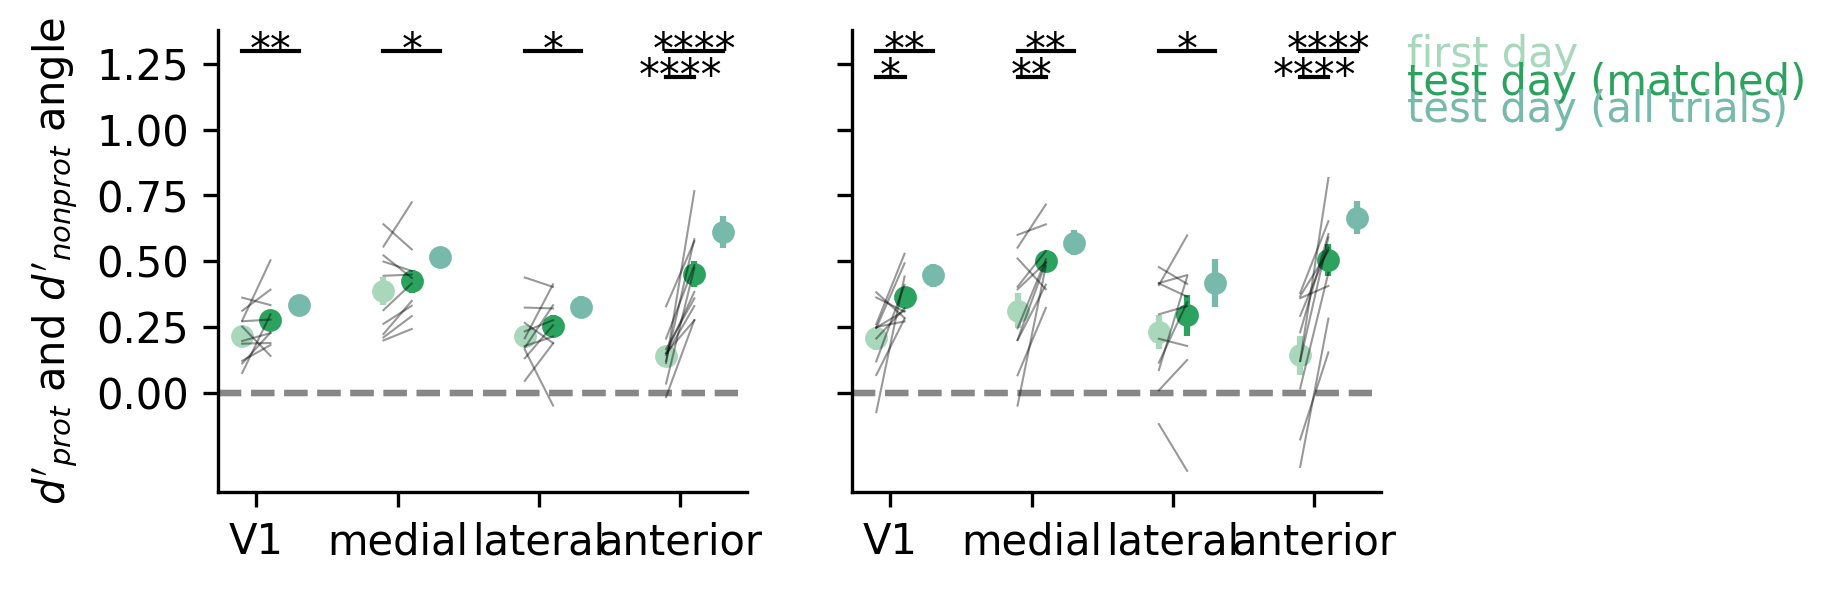

In [99]:
from src import fig1
gis_first = angles['first training']
gis_last = angles['last training']
gis_last_m = angles['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=1.2, sig_line_control=1.3, ylabel='$d\'_{prot}$ and $d\'_{non prot}$ angle')
sns.despine()

In [100]:
df_no34 = dp_invariance_df.query("name != 'VG34'") #we don't have the all rew after 

In [101]:
sessions = ['all rewarded before', 'all rewarded after']
areas = ['V1', 'medial', 'lateral', 'anterior']
celltype = ['Pyr', 'Int']
nmice = 9 # only 9 sessions
for sess in sessions: 
    inv_index = np.empty((nmice, len(areas), len(celltype)))
    inv_index_nonprot = np.empty((nmice, len(areas), len(celltype)))
    for ia, area in enumerate(areas):
        for ic, ctype in enumerate(celltype):
            inv = get_invariance(df_no34, area, ctype, sess)
            inv_index[:,ia,ic] = inv
    invariances[sess] = inv_index

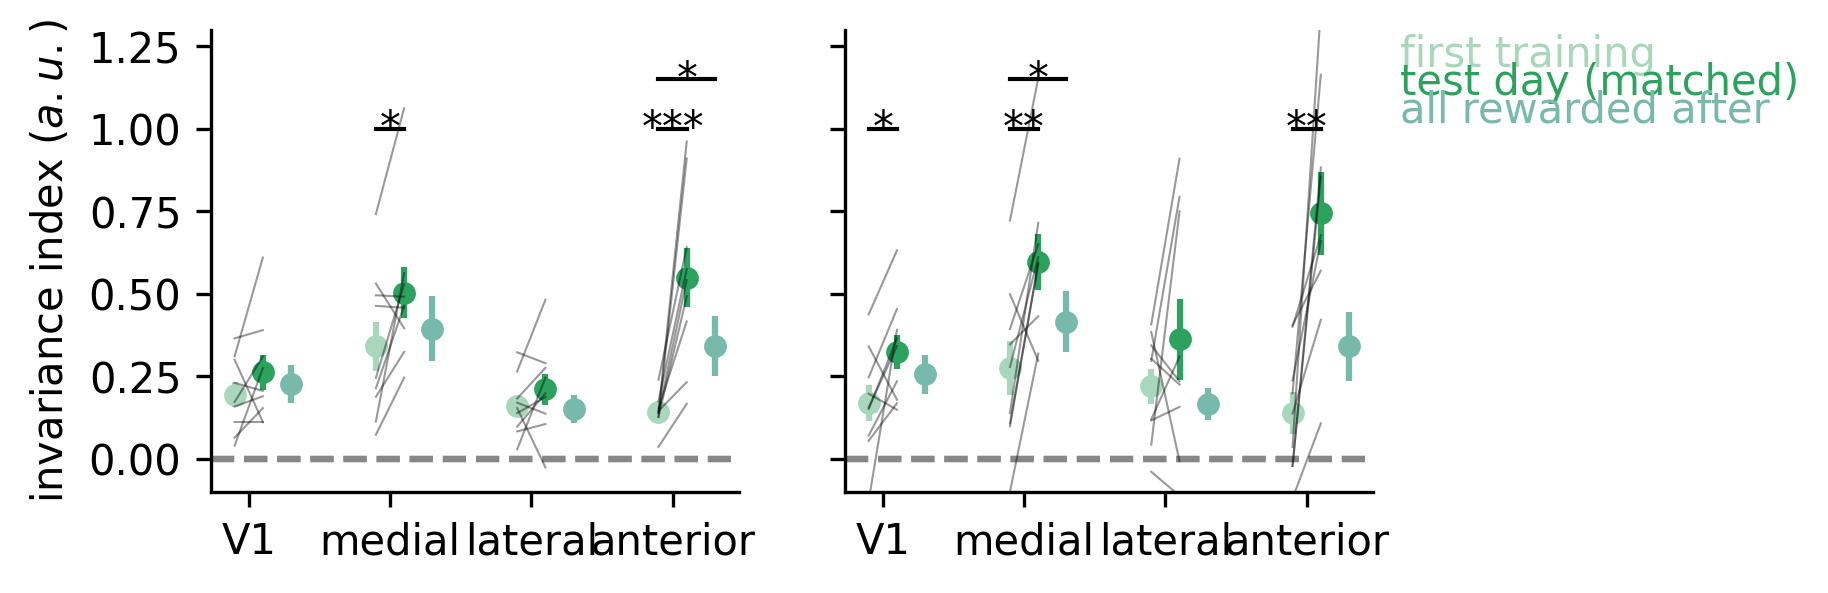

In [105]:
gis_first = np.delete(invariances['first training'], 8, axis=0)
gis_last = invariances['all rewarded after']
gis_last_m = np.delete(invariances['last training (matched)'], 8, axis=0)
fig, ax = plt.subplots(1,2, figsize=(5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=1, sig_line_control=1.15, labels=["first training", "test day (matched)", "all rewarded after"])
plt.ylim(-0.1, 1.3)
sns.despine()

In [102]:
sessions = ['all rewarded before', 'all rewarded after']
areas = ['V1', 'medial', 'lateral', 'anterior']
celltype = ['Pyr', 'Int']
nmice = 9
for sess in sessions: 
    angle = np.empty((nmice, len(areas), len(celltype)))
    for ia, area in enumerate(areas):
        for ic, ctype in enumerate(celltype):
            inv = get_feature_values(df_no34, area, ctype, sess, 'angle')
            #store values
            angle[:,ia,ic] = inv
    angles[sess] = angle

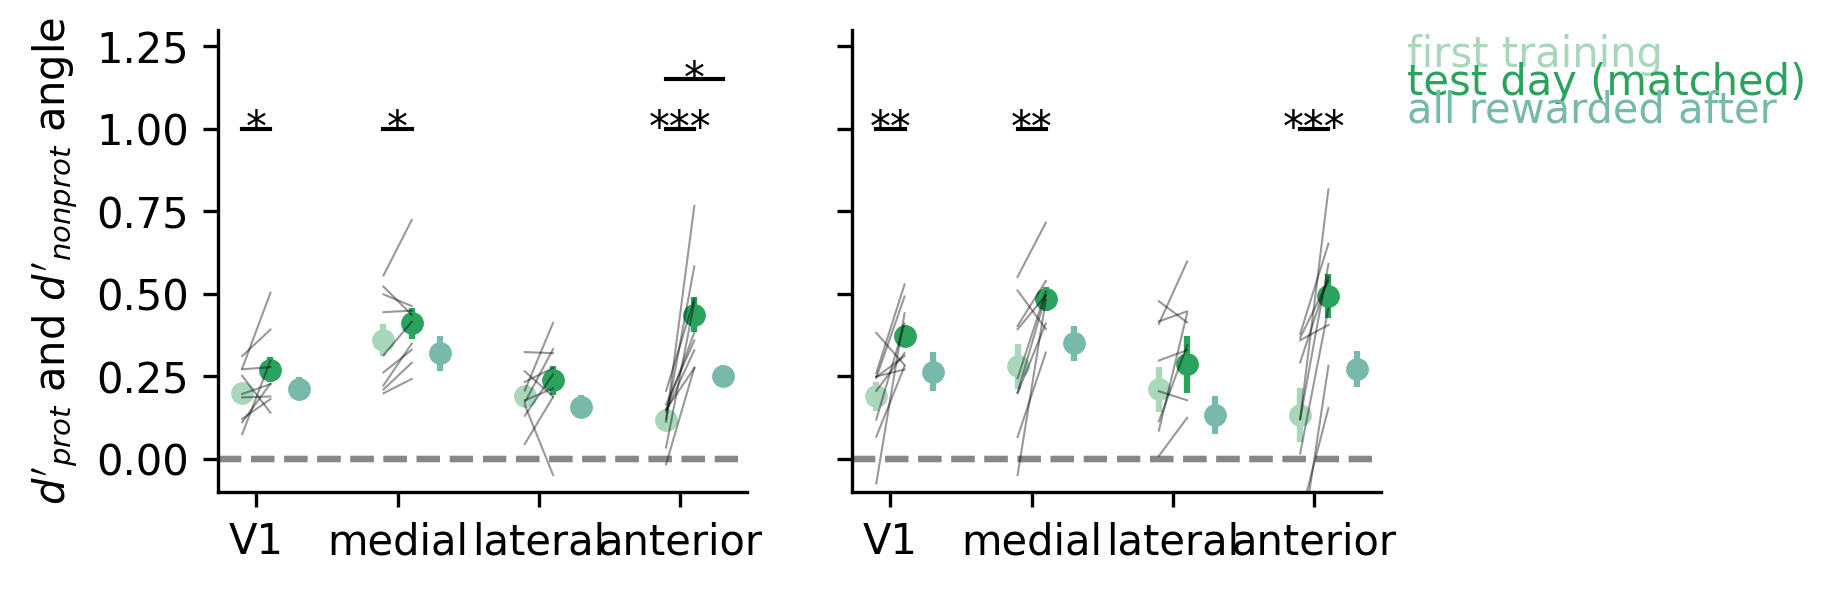

In [106]:
gis_first = np.delete(angles['first training'], 8, axis=0)
gis_last = angles['all rewarded after']
gis_last_m = np.delete(angles['last training (matched)'], 8, axis=0)
fig, ax = plt.subplots(1,2, figsize=(5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=1, sig_line_control=1.15, labels=["first training", "test day (matched)", "all rewarded after"], ylabel='$d\'_{prot}$ and $d\'_{non prot}$ angle')
plt.ylim(-0.1, 1.3)
sns.despine()

In [119]:
ft_inv=invariances["first training"]
ft_inv = ft_inv[:, :, 0]  # Pyr cells only
#compare the difference between areas means and plot as point plot, with ttest rel
area_names = ['V1', 'medial', 'lateral', 'anterior']


C:\Users\labadmin\AppData\Local\Temp\ipykernel_27496\1158865642.py:15: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=df_ft, x='area', y='invariance', errorbar='se', capsize=0.15,


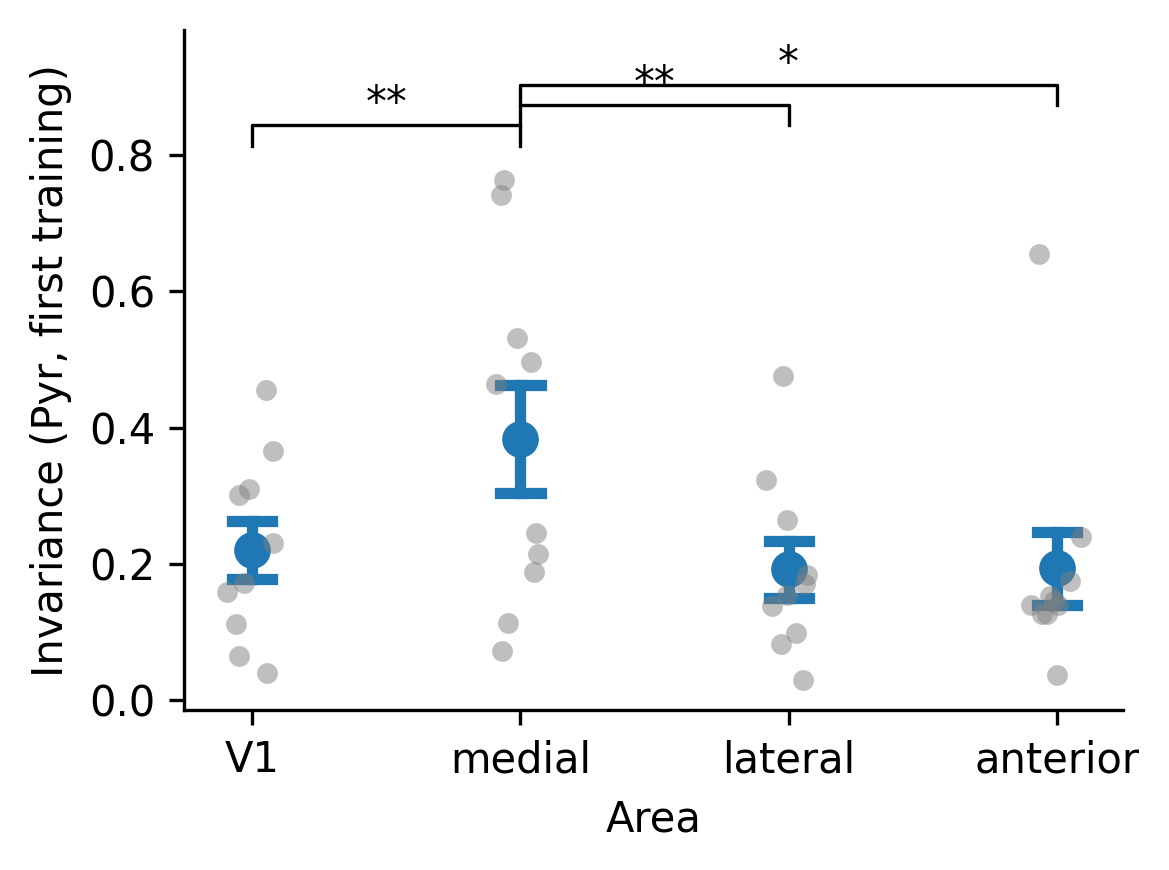

In [120]:
from itertools import combinations
from scipy.stats import ttest_rel

# ft_inv: shape (nmice, nareas) for Pyr cells on first training
nmice, nareas = ft_inv.shape
df_ft = pd.DataFrame({
    'mouse': np.repeat(np.arange(nmice), nareas),
    'area': np.tile(area_names, nmice),
    'invariance': ft_inv.reshape(-1)
})

fig, ax = plt.subplots(figsize=(4,3), dpi=300)

# Mean ± SEM pointplot + individual points
sns.pointplot(data=df_ft, x='area', y='invariance', errorbar='se', capsize=0.15,
              join=False, color='tab:blue', ax=ax)
sns.stripplot(data=df_ft, x='area', y='invariance', color='gray', alpha=0.5, ax=ax)

ax.set_ylabel("Invariance (Pyr, first training)")
ax.set_xlabel("Area")
sns.despine(ax=ax)

def add_sig_line(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=0.8, c='k')
    ax.text((x1 + x2) / 2, y + h, text, ha='center', va='bottom')

# Pairwise paired t-tests across areas; annotate only significant pairs
pairs_idx = list(combinations(range(len(area_names)), 2))
y_base = df_ft['invariance'].max() + 0.05
h = 0.03
stack = 0

for i, j in pairs_idx:
    a = ft_inv[:, i]
    b = ft_inv[:, j]
    mask = ~np.isnan(a) & ~np.isnan(b)
    if mask.sum() < 2:
        continue
    tstat, pval = ttest_rel(a[mask], b[mask])
    if pval < 0.05:
        stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*'
        y = y_base + stack * 0.03
        add_sig_line(ax, i, j, y, h, stars)
        stack += 1

# Expand ylim if any annotations were drawn
if stack > 0:
    ax.set_ylim(top=y_base + stack * 0.04 + 0.05)

plt.tight_layout()

C:\Users\labadmin\AppData\Local\Temp\ipykernel_27496\2053154052.py:19: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=df_ft, x='area', y='invariance', errorbar='se', capsize=0.15,


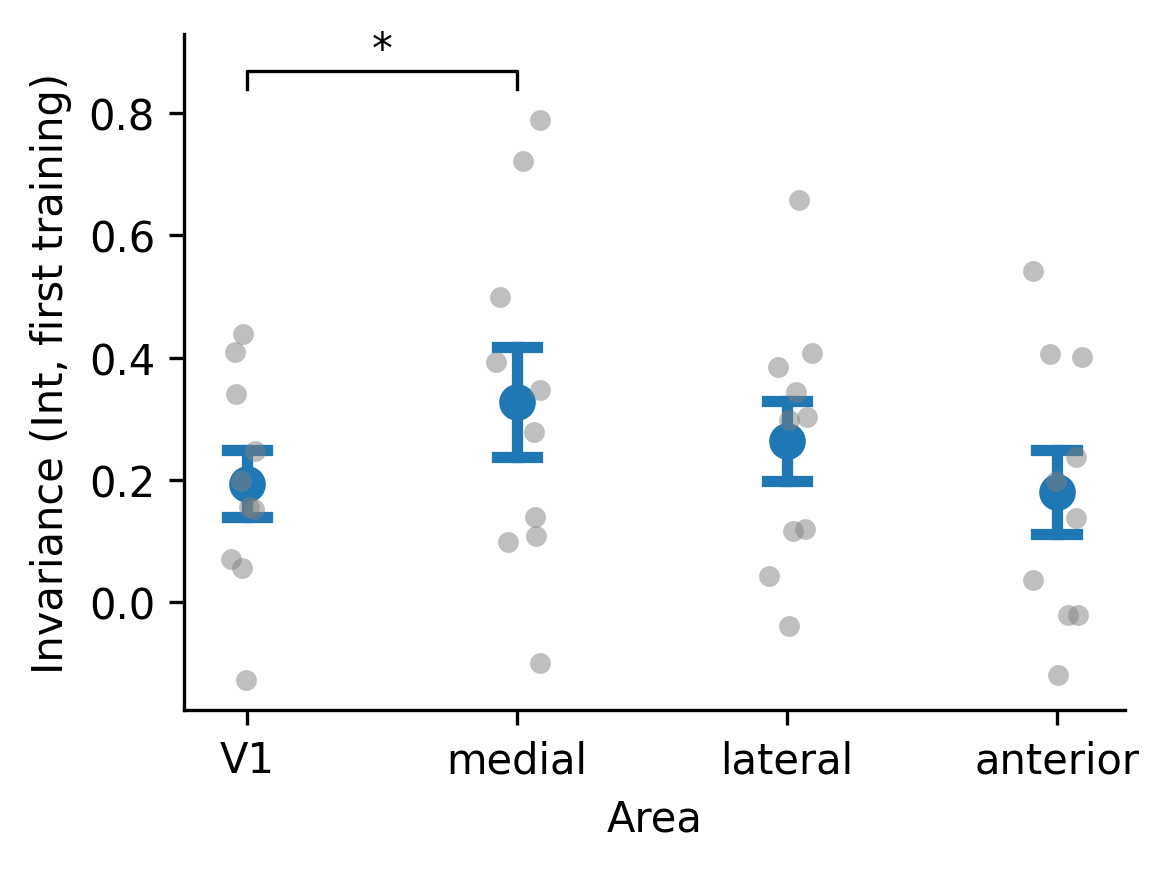

In [121]:
ft_inv=invariances["first training"]
ft_inv = ft_inv[:, :, 1]  # Inhibitory cells only
#compare the difference between areas means and plot as point plot, with ttest rel
area_names = ['V1', 'medial', 'lateral', 'anterior']
from itertools import combinations
from scipy.stats import ttest_rel

# ft_inv: shape (nmice, nareas) for Pyr cells on first training
nmice, nareas = ft_inv.shape
df_ft = pd.DataFrame({
    'mouse': np.repeat(np.arange(nmice), nareas),
    'area': np.tile(area_names, nmice),
    'invariance': ft_inv.reshape(-1)
})

fig, ax = plt.subplots(figsize=(4,3), dpi=300)

# Mean ± SEM pointplot + individual points
sns.pointplot(data=df_ft, x='area', y='invariance', errorbar='se', capsize=0.15,
              join=False, color='tab:blue', ax=ax)
sns.stripplot(data=df_ft, x='area', y='invariance', color='gray', alpha=0.5, ax=ax)

ax.set_ylabel("Invariance (Int, first training)")
ax.set_xlabel("Area")
sns.despine(ax=ax)

def add_sig_line(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=0.8, c='k')
    ax.text((x1 + x2) / 2, y + h, text, ha='center', va='bottom')

# Pairwise paired t-tests across areas; annotate only significant pairs
pairs_idx = list(combinations(range(len(area_names)), 2))
y_base = df_ft['invariance'].max() + 0.05
h = 0.03
stack = 0

for i, j in pairs_idx:
    a = ft_inv[:, i]
    b = ft_inv[:, j]
    mask = ~np.isnan(a) & ~np.isnan(b)
    if mask.sum() < 2:
        continue
    tstat, pval = ttest_rel(a[mask], b[mask])
    if pval < 0.05:
        stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*'
        y = y_base + stack * 0.03
        add_sig_line(ax, i, j, y, h, stars)
        stack += 1

# Expand ylim if any annotations were drawn
if stack > 0:
    ax.set_ylim(top=y_base + stack * 0.04 + 0.05)

plt.tight_layout()

In [ ]:
def mistakes_analysis(m, area, trial_dict):
    from scipy.stats import pearsonr
    all_means = m.interp_spks[:,:,:100].mean(2)
    all_means = all_means[area,:]
    all_means = all_means.T  
    is_exc = np.logical_not(m.isred[area, 0]).astype(bool)
    is_inh = m.isred[area, 0].astype(bool)
    means_exc = all_means[:, is_exc]  # Excitatory neurons
    means_inh = all_means[:, is_inh]  # Inhibitory neuron
    Rprot, NRprot, Rrest, NRrest = trial_dict["rewarded"], trial_dict["non rewarded"], trial_dict["rewarded test"], trial_dict["non rewarded test"]
    correct, incorrect = utils.build_correct_dicts(m)
    correct_protA = np.intersect1d(correct["rewarded"], Rprot)
    correct_protB = np.intersect1d(correct["non rewarded"], NRprot)
    w_exc = means_exc[correct_protA].mean(0) - means_exc[correct_protB].mean(0)
    w_inh = means_inh[correct_protA].mean(0) - means_inh[correct_protB].mean(0)

    # project all trials 
    p_e = means_exc @ w_exc
    p_i = means_inh @ w_inh
    #lets zscore them agaisnt the non rewarded prototype trials
    z_e = (p_e - p_e[NRprot].mean()) / (p_e[NRprot].std() + 1e-6)
    z_i = (p_i - p_i[NRprot].mean()) / (p_i[NRprot].std() + 1e-6)
    #now 0 is the non rewarded state , lets grab each projection for the rest trials
    z_e_hit = z_e[correct["rewarded test"]]
    z_i_hit = z_i[correct["rewarded test"]]
    z_e_cr = z_e[correct["non rewarded test"]]
    z_i_cr = z_i[correct["non rewarded test"]]
    z_e_om = z_e[incorrect["rewarded test"]]
    z_i_om = z_i[incorrect["rewarded test"]]
    z_e_fa = z_e[incorrect["non rewarded test"]]
    z_i_fa = z_i[incorrect["non rewarded test"]]
    scores_exc = {"hit": z_e_hit,
                "correct rejection": z_e_cr,
                "miss": z_e_om,
                "false alarm": z_e_fa}
    scores_inh = {"hit": z_i_hit,
                "correct rejection": z_i_cr,
                "miss": z_i_om,
                "false alarm": z_i_fa}
    alignment_r_correct, _ = pearsonr(np.concatenate([scores_exc["hit"], scores_exc["correct rejection"]]), np.concatenate([scores_inh["hit"], scores_inh["correct rejection"]]))
    alignment_r_incorrect, _ = pearsonr(np.concatenate([scores_exc["miss"], scores_exc["false alarm"]]), np.concatenate([scores_inh["miss"], scores_inh["false alarm"]]))
    return scores_exc, scores_inh, alignment_r_correct, alignment_r_incorrect

In [206]:
sessions_names = ['last training (matched)']

In [213]:
rows = []
obj_path = Path(r"D:\mouseobj")
for iss, sess in enumerate(sessions_names):
    if sess == 'last training (matched)':
        session = 'last training'
    else:
        session = sess
    d = working_dbase.query(f"session == '{session}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        save_pth = obj_path.joinpath(name,datexp,blk)
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        if sess == 'last training (matched)':
            t_dict = get_matched_trials(m)
        else:
            t_dict = m.trial_dict
        scores_dict_exc = {area: {} for area in areas}
        scores_dict_inh = {area: {} for area in areas}
        for iaa, area in enumerate(areas):
            ia = utils.get_region_idx(m.iarea, area)
            scores_exc, scores_inh, alignment_r_correct, alignment_r_incorrect = mistakes_analysis(m, ia, t_dict)
            scores_dict_exc[area] = scores_exc
            scores_dict_inh[area] = scores_inh
            rows.append({'name': name, 'datexp': datexp, 'blk': blk, 
                         'session': sess, 'area': area, 
                         'alignment_r_correct': alignment_r_correct,
                         'alignment_r_incorrect': alignment_r_incorrect})
        np.save(save_pth.joinpath("exc_scores_mistake_analysis.npy"), scores_dict_exc)
        np.save(save_pth.joinpath("inh_scores_mistake_analysis.npy"), scores_dict_inh)
    clear_output(wait=True)
alignment_df = pd.DataFrame(rows)

Processing: last training (matched)
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_10_31\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_14\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG

In [215]:
id_vars = [c for c in ['name', 'datexp', 'blk', 'session', 'area', 'celltype'] if c in alignment_df.columns]
alignment_long = alignment_df.melt(
    id_vars=id_vars,
    value_vars=['alignment_r_correct', 'alignment_r_incorrect'],
    var_name='accuracy',
    value_name='alignment'
)

# Map accuracy labels to tidy values
acc_map = {'alignment_r_correct': 'correct', 'alignment_r_incorrect': 'incorrect'}
alignment_long['accuracy'] = alignment_long['accuracy'].map(acc_map)

In [216]:
alignment_long.to_csv(r"D:\mouseobj\overall\ei_alignment_mistake_analysis.csv", index=False)

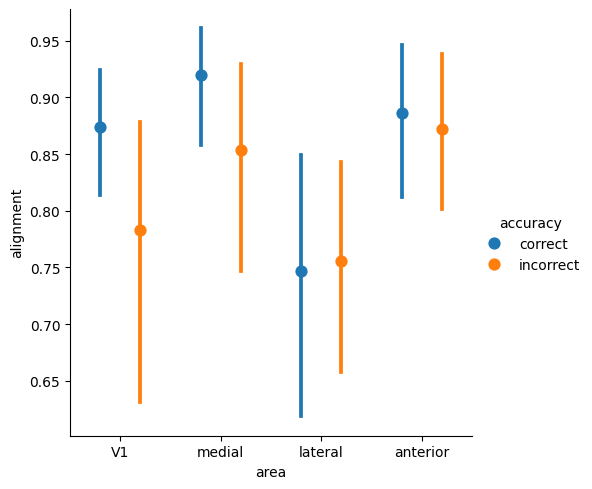

In [217]:
sns.catplot(data=alignment_long.query("session == 'last training (matched)'"), x='area', y='alignment',hue='accuracy', kind='point', width=4, aspect=1, dodge=.4, linestyle='none')

In [220]:
obj_path = Path(r"D:\mouseobj")
d = working_dbase.query(f"session == 'last training'")
grand_scores_exc = {area: {"hit": [], "correct rejection": [], "miss": [], "false alarm": []} for area in areas}
grand_scores_inh = {area: {"hit": [], "correct rejection": [], "miss": [], "false alarm": []} for area in areas}
outputs = ["hit", "correct rejection", "miss", "false alarm"]
rows = []
for i, (_, row) in enumerate(d.iterrows()):
    name, datexp, blk = row["mname"], row["datexp"], row["blk"]
    save_pth = obj_path.joinpath(name,datexp,blk)
    scores_exc = np.load(save_pth.joinpath("exc_scores_mistake_analysis.npy"), allow_pickle=True).item()
    scores_inh = np.load(save_pth.joinpath("inh_scores_mistake_analysis.npy"), allow_pickle=True).item()
    for iaa, area in enumerate(areas):
        rows.append({'name': name, 'datexp': datexp, 'blk': blk, 
                    'session': sess, 'celltype': 'exc', 'area': area,
                    'hit': scores_exc[area]['hit'].mean(),
                    'correct_rejection': scores_exc[area]['correct rejection'].mean(),
                    'miss': scores_exc[area]['miss'].mean(),
                    'false_alarm': scores_exc[area]['false alarm'].mean()})
        rows.append({'name': name, 'datexp': datexp, 'blk': blk, 
                'session': sess, 'celltype': 'inh', 'area': area,
                'hit': scores_inh[area]['hit'].mean(),
                'correct_rejection': scores_inh[area]['correct rejection'].mean(),
                'miss': scores_inh[area]['miss'].mean(),
                'false_alarm': scores_inh[area]['false alarm'].mean()})
        for output in outputs:
            grand_scores_inh[area][output].extend(scores_inh[area][output])
            grand_scores_exc[area][output].extend(scores_exc[area][output])
proj_scores_df = pd.DataFrame(rows)

In [222]:
output_vars = [c for c in ['hit', 'correct_rejection', 'miss', 'false_alarm'] if c in proj_scores_df.columns]

In [225]:
proj_scores_melted = proj_scores_df.melt(id_vars=['name', 'datexp', 'blk', 'session', 'celltype', 'area'], value_vars=output_vars, var_name='output', value_name='score')

In [226]:
proj_scores_melted.to_csv(r"D:\mouseobj\overall\projection_scores_means_mistake_analysis.csv", index=False)

In [3]:
proj_scores_melted = pd.read_csv(r"D:\mouseobj\overall\projection_scores_means_mistake_analysis.csv")

In [4]:
palette =["#0072B2","#D55E00", "#56B4E9","#E69F00"]

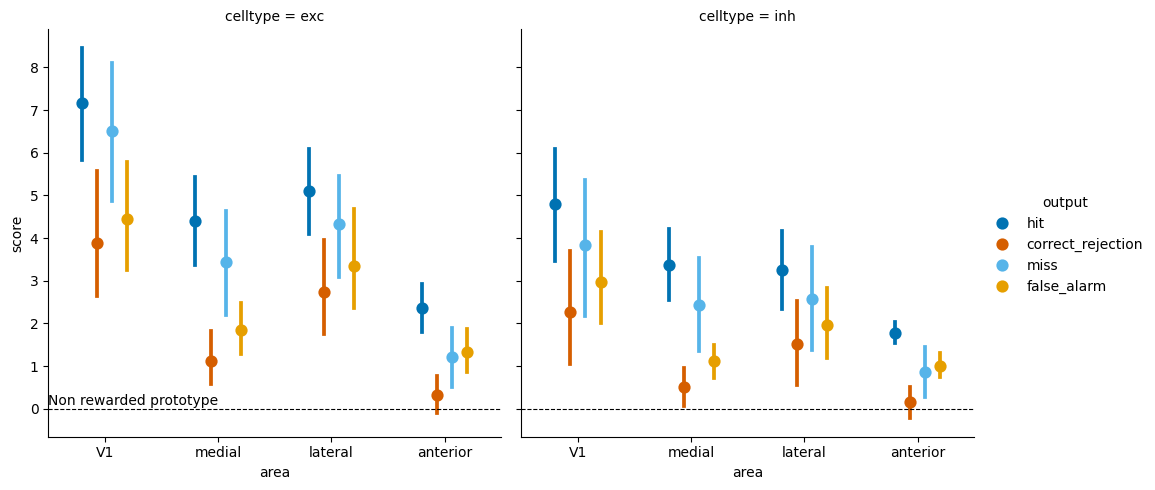

In [5]:
g = sns.catplot(data=proj_scores_melted, x='area', y='score', hue='output', col='celltype', kind='point', width=4, aspect=1, dodge=.4, linestyle='none', palette=palette)
#add line at y=
g.set(yticks=[0, 1, 2, 3, 4, 5,6, 7,8])
for iax, ax in enumerate(g.axes.flat):
    ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
    if iax == 0:
        ax.text(-0.5, 0.01, 'Non rewarded prototype', transform=ax.transData, fontsize=10, verticalalignment='bottom')

In [14]:
def get_mean_se_pergroup(area, celltype, output, df):
    from scipy import stats
    vals = df.query(f"celltype == '{celltype}' & area == '{area}' & output == '{output}'")["score"].values
    mean_ = np.mean(vals)
    se_ =  stats.sem(vals)
    return mean_, se_, vals


In [16]:
mn, se, vals = get_mean_se_pergroup('V1', 'exc', 'hit', proj_scores_melted)

In [50]:
proj_scores_melted.output.unique()

array(['hit', 'correct_rejection', 'miss', 'false_alarm'], dtype=object)

In [33]:
from scipy.stats import ttest_rel

In [90]:
def plot_scores(ax, celltype, proj_scores_melted, reflabel=False, legend=False, ylabel=False):
    palette =["#0072B2","#D55E00", "#56B4E9","#E69F00"]
    areas = ['V1', 'medial', 'lateral', 'anterior']
    for ia, area in enumerate(areas):
        mn_1, se_1, vals_1 = get_mean_se_pergroup(area, celltype, 'hit', proj_scores_melted)
        ax.errorbar(ia-.2, mn_1, se_1, c=palette[0])
        ax.scatter(ia-.2, mn_1, s=10, c=palette[0])
        mn_2, se_2, vals_2 = get_mean_se_pergroup(area, celltype, 'miss', proj_scores_melted)
        ax.errorbar(ia-.1, mn_2, se_2, c=palette[2])
        ax.scatter(ia-.1, mn_2, s=10, c=palette[2])
        ax.plot([ia-.2, ia-.1], [vals_1, vals_2], 'k-', alpha=0.3, linewidth=0.5, zorder=0);
        tstat, pval = ttest_rel(vals_1, vals_2)
        if pval < 0.05:
            stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*'
            ax.text(ia-.15, max(vals_1) + 0.1, stars, ha='center', va='bottom')

        mn_1, se_1, vals_1 = get_mean_se_pergroup(area, celltype, 'correct_rejection', proj_scores_melted)
        ax.errorbar(ia+.1, mn_1, se_1, c=palette[1])
        ax.scatter(ia+.1, mn_1, s=10, c=palette[1])
        mn_2, se_2, vals_2 = get_mean_se_pergroup(area, celltype, 'false_alarm', proj_scores_melted)
        ax.errorbar(ia+.2, mn_2, se_2, c=palette[3])
        ax.scatter(ia+.2, mn_2, s=10, c=palette[3])
        ax.plot([ia+.1, ia+.2], [vals_1, vals_2], 'k-', alpha=0.3, linewidth=0.5, zorder=0);

        tstat, pval = ttest_rel(vals_1, vals_2)
        if pval < 0.05:
            stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*'
            ax.text(ia+.15, max(vals_2) + 0.1, stars, ha='center', va='bottom')
    if legend:
        outputs = ["Hit", "Correct rejection", "Miss", "False alarm"]
        ylims = ax.get_ylim()
        for c, output in enumerate(outputs):
            ax.text(3.5, ylims[1]- c*.7, output, c=palette[c], label=output, fontsize=9, verticalalignment='center')
    ax.set_xticks([0, 1, 2 , 3], ['V1', 'medial', 'lateral', 'anterior'])
    ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
    if reflabel:
        ax.text(4, 0, 'Non rewarded prototype', fontsize=8, verticalalignment='center')
    if ylabel:
        ax.set_ylabel('Z-scored projection score \n (non prototypes)')
    ax.set_ylim(-0.5,11)
    ax.set_xlim(-.5,4)
    sns.despine()

Text(0.5, 1.0, 'Inhibitory neurons')

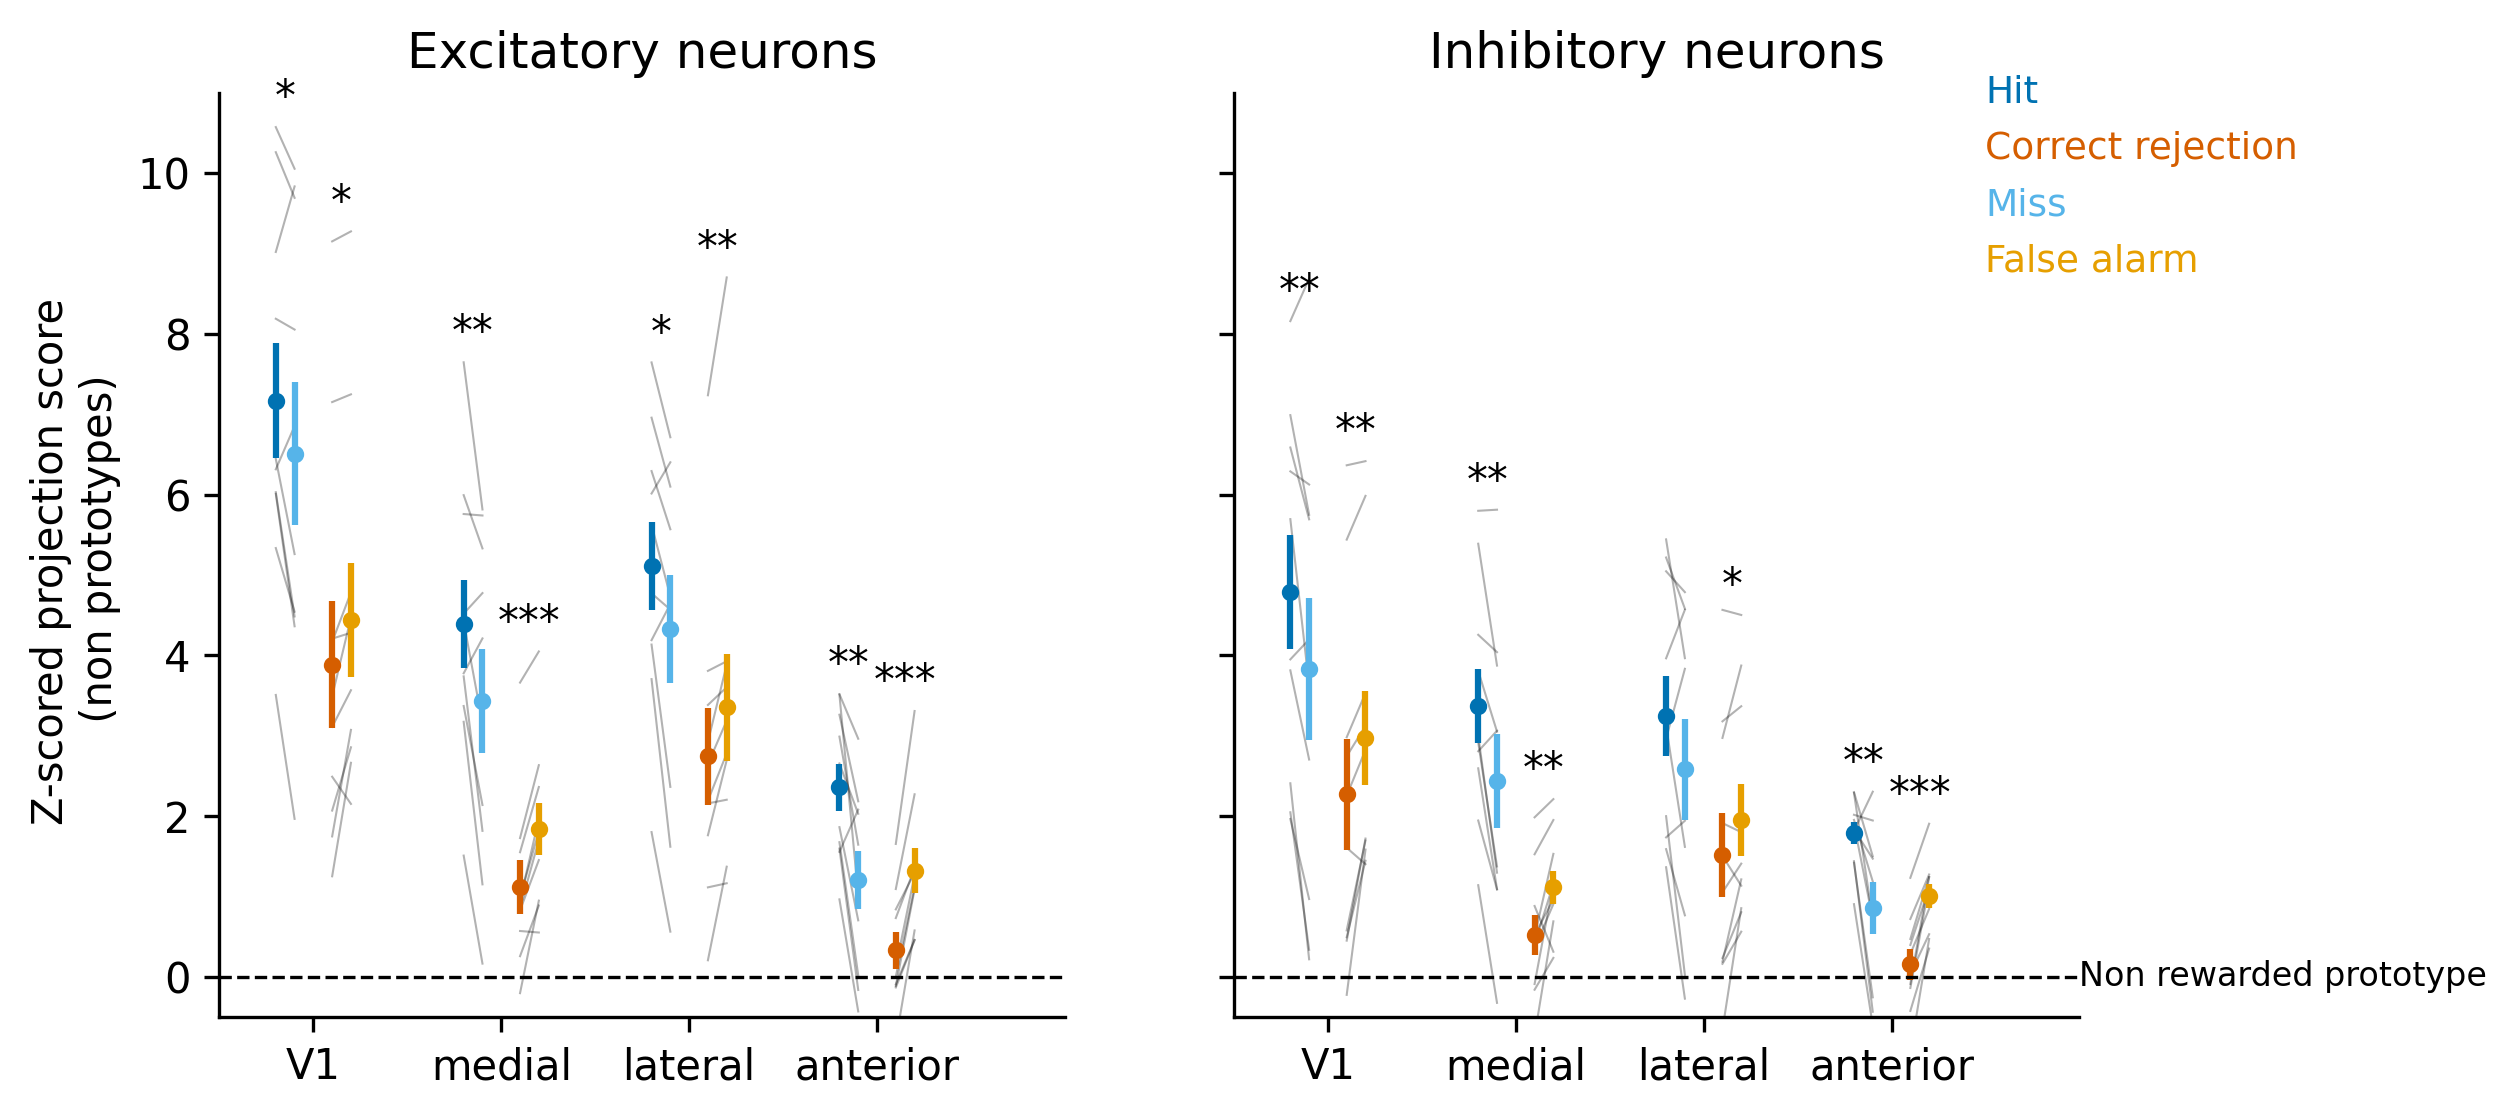

In [92]:
fig, ax = plt.subplots(1,2, figsize=(8,4), dpi=300, sharey=True)
plot_scores(ax[0], 'exc', proj_scores_melted, ylabel=True)
ax[0].set_title('Excitatory neurons')
plot_scores(ax[1], 'inh', proj_scores_melted, legend=True, reflabel=True, ylabel=False)
ax[1].set_title('Inhibitory neurons')

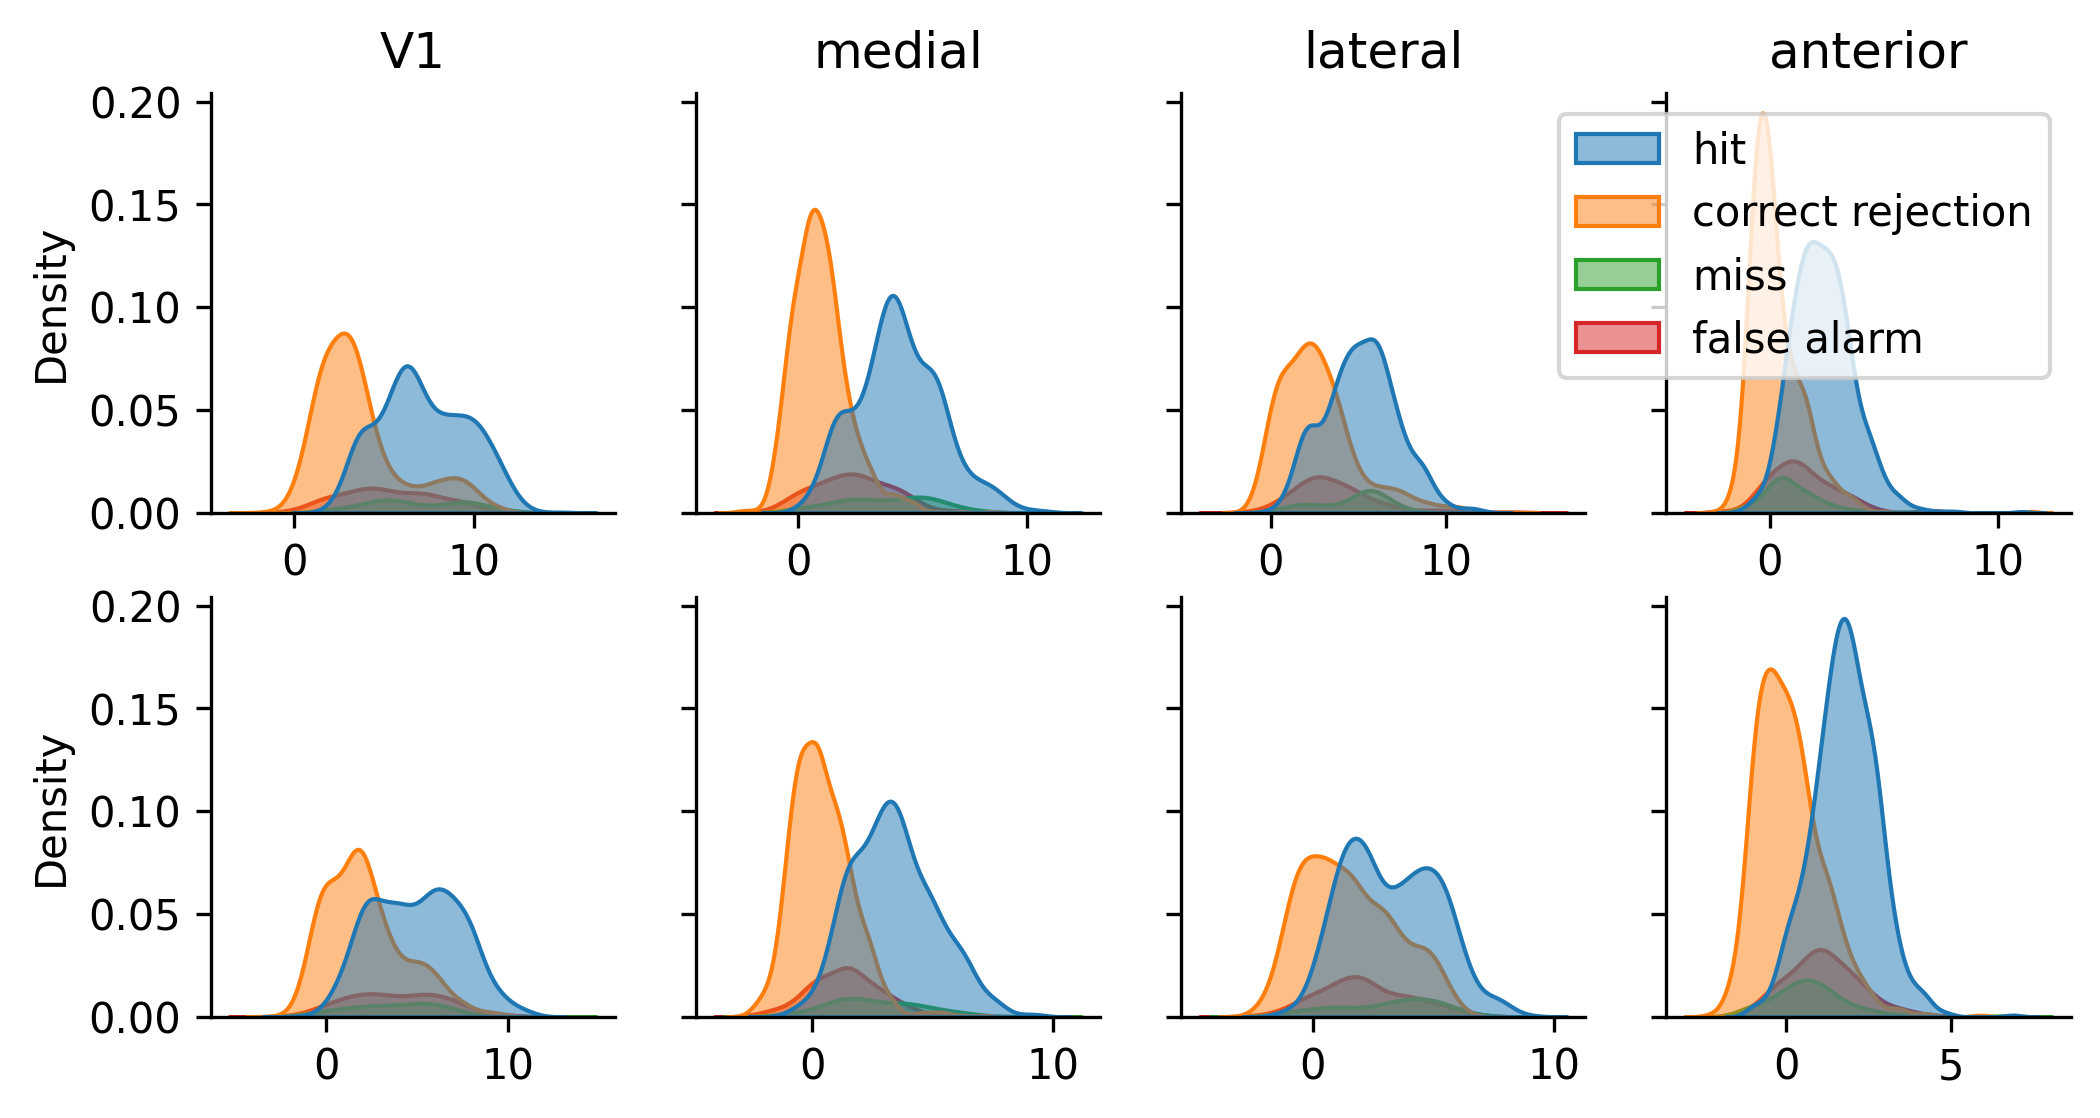

In [236]:
fig, ax = plt.subplots(2,4, figsize=(8,4), dpi=300, sharey=True)
for i, area in enumerate(areas):
    if i == 3:
        sns.kdeplot(grand_scores_exc[area], fill=True, alpha=0.5, ax=ax[0, i], legend=True)
    else:
        sns.kdeplot(grand_scores_exc[area], fill=True, alpha=0.5, ax=ax[0, i], legend=False)
    sns.kdeplot(grand_scores_inh[area], fill=True, alpha=0.5, ax=ax[1, i], legend=False)
    ax[0, i].set_title(f"{area}")
sns.despine()

In [260]:
behav_sess = working_dbase.query("session == 'last training'").reset_index(drop=True)

In [261]:
behav_sess

,mname,datexp,blk,session,round_id,recording,obj
0,VG11,2024_10_31,2,last training,1,True,old
1,VG11,2024_11_14,2,last training,2,True,old
2,VG14,2024_11_21,2,last training,1,True,old
3,VG15,2024_10_31,2,last training,1,True,old
4,VG21,2025_07_17,3,last training,1,True,old
5,VG21,2025_08_07,2,last training,2,True,old
6,VG24,2025_07_10,2,last training,1,True,old
7,VG33,2025_10_09,3,last training,1,True,old
8,VG34,2025_10_10,3,last training,1,True,old
9,VGa9,2025_11_20,2,last training,1,True,new


In [322]:
feature_means_mistakes = np.zeros((10, 5, 2, 2, 800)) # mice, features, rewarded/non-rewarded, correct/incorrect, position
for im, sess in behav_sess.iterrows():
    name, date, blk = sess['mname'], sess['datexp'], sess['blk']
    m = utils.load_mouse(name, date, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj") 
    speed, lick_rate, delta_motion, delta_pupil = behavmatch.load_behav_data(m, delta=False) # on D motion and ppupil are already deltas
    save_pth = obj_path.joinpath(name,date,blk)
    acc = behavmatch.compute_acceleration(speed, ew=.3)
    features = [lick_rate, speed, acc, delta_pupil, delta_motion]
    correct, incorrect = utils.build_correct_dicts(m)
    neurons, trials, positions = m.interp_spks.shape
    correct_rew = np.concatenate([correct["rewarded"], correct["rewarded test"]])
    correct_nrew = np.concatenate([correct["non rewarded"], correct["non rewarded test"]])
    incorrect_rew = np.concatenate([incorrect["rewarded"], incorrect["rewarded test"]])
    incorrect_nrew = np.concatenate([incorrect["non rewarded"], incorrect["non rewarded test"]])
    lagged_correct_rew = correct_rew - 1
    lagged_correct_nrew = correct_nrew - 1
    lagged_incorrect_rew = incorrect_rew - 1
    lagged_incorrect_nrew = incorrect_nrew - 1
    #verify if the lagged indices are valid
    lagged_correct_rew = lagged_correct_rew[lagged_correct_rew >= 0]
    lagged_correct_nrew = lagged_correct_nrew[lagged_correct_nrew >= 0]
    lagged_incorrect_rew = lagged_incorrect_rew[lagged_incorrect_rew >= 0]
    lagged_incorrect_nrew = lagged_incorrect_nrew[lagged_incorrect_nrew >= 0]
    for i_f, feature in enumerate(features):
        # Rewarded trials
        feature_means_mistakes[im, i_f, 0, 0, 400:] = feature[correct_rew].mean(0)
        feature_means_mistakes[im, i_f, 0, 1, 400:] = feature[incorrect_rew].mean(0)
        # Non-rewarded trials
        feature_means_mistakes[im, i_f, 1, 0, 400:] = feature[correct_nrew].mean(0)
        feature_means_mistakes[im, i_f, 1, 1, 400:] = feature[incorrect_nrew].mean(0)
        # Lagged version
        # Rewarded trials
        feature_means_mistakes[im, i_f, 0, 0, :400] = feature[lagged_correct_rew].mean(0)
        feature_means_mistakes[im, i_f, 0, 1, :400] = feature[lagged_incorrect_rew].mean(0)
        # Non-rewarded trials
        feature_means_mistakes[im, i_f, 1, 0, :400] = feature[lagged_correct_nrew].mean(0)
        feature_means_mistakes[im, i_f, 1, 1, :400] = feature[lagged_incorrect_nrew].mean(0)

Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_10_31\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_14\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG14\2024_11_21\2
Existing mouse objec

In [338]:
from scipy.stats import sem
palette =["#0072B2","#D55E00", "#56B4E9","#E69F00"]
def plot_catvsbehav(behav_cov_catA, behav_cov_catB, ylabel, xlabel, ax, legend=False, onlymistake=False):
    cat_a_correct = behav_cov_catA[:,0,300:]
    cat_b_correct = behav_cov_catB[:,0,300:]
    cat_a_incorrect = behav_cov_catA[:,1,300:]
    cat_b_incorrect = behav_cov_catB[:,1,300:]
    if onlymistake:
        ax.plot(cat_a_incorrect.mean(0), color=palette[0], linestyle='--', label='Miss')
        ax.fill_between(np.arange(500), cat_a_incorrect.mean(0)-sem(cat_a_incorrect, axis=0), cat_a_incorrect.mean(0)+sem(cat_a_incorrect, axis=0), alpha=0.3, color=palette[0])
        ax.plot(cat_b_incorrect.mean(0), color=palette[1], linestyle='--', label='False Alarm')
        ax.fill_between(np.arange(500), cat_b_incorrect.mean(0)-sem(cat_b_incorrect, axis=0), cat_b_incorrect.mean(0)+sem(cat_b_incorrect, axis=0), alpha=0.3, color=palette[1])
    else:
        ax.plot(cat_a_correct.mean(0), color=palette[0], linestyle='-', label='Hit')
        ax.fill_between(np.arange(500), cat_a_correct.mean(0)-sem(cat_a_correct, axis=0), cat_a_correct.mean(0)+sem(cat_a_correct, axis=0), alpha=0.3, color=palette[0])
        ax.plot(cat_b_correct.mean(0), color=palette[1], linestyle='-', label='Correct Rejection')
        ax.fill_between(np.arange(500), cat_b_correct.mean(0)-sem(cat_b_correct, axis=0), cat_b_correct.mean(0)+sem(cat_b_correct, axis=0), alpha=0.3, color=palette[1])
    ax.set_ylabel(ylabel)
    ax.set_xticks([0, 100, 250, 350, 400, 500], ['prev inter', 'current t', '150', '250', '300', '400'], rotation=90)    
    if legend:
        ax.legend(bbox_to_anchor=(1.05, .9), fontsize=12, frameon=False)
    if xlabel:
        ax.set_xlabel("Position (cm)")
    #fill between 0 and 100 with gray
    ymin, ymax = ax.get_ylim()
    ax.fill_between(np.arange(100,200), ymin, ymax, color='gray', alpha=0.2)
    ax.axvline(100, color='k', linestyle='-', alpha=0.7)
    ax.axvline(250, color='k', linestyle='--', alpha=0.3)
    ax.axvline(350, color='k', linestyle='--', alpha=0.3)
    ax.axvline(400, color='k', linestyle='--', alpha=0.3)

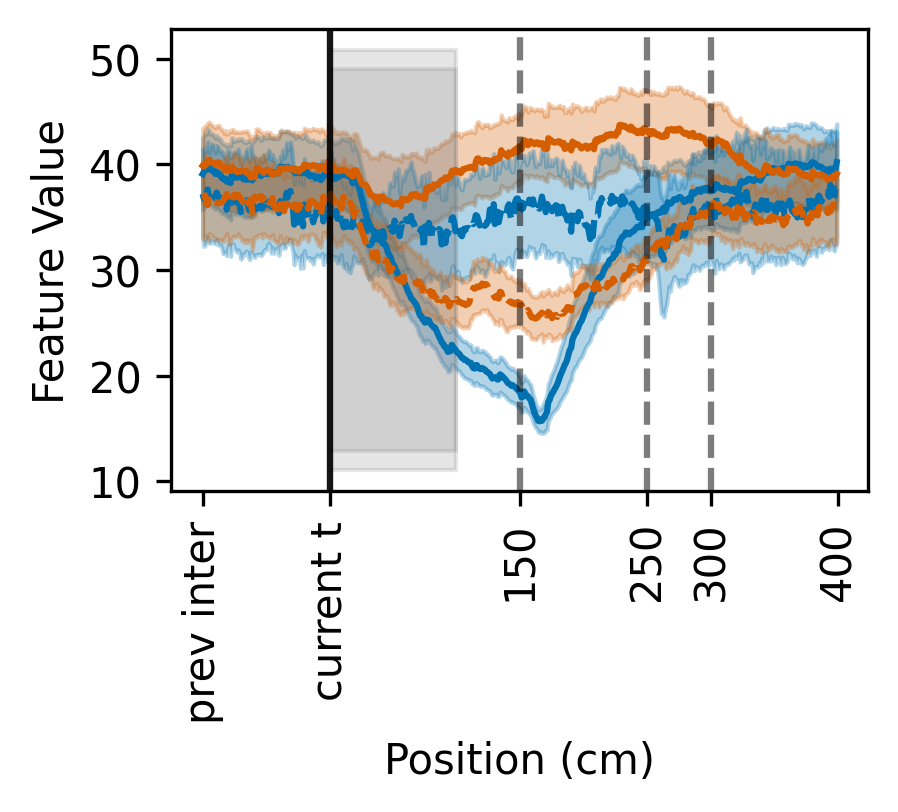

In [339]:
fig, ax = plt.subplots(1,1, figsize=(3,2), dpi=300, sharey=True)
plot_catvsbehav(feature_means_mistakes[:,1, 0], feature_means_mistakes[:, 1, 1], xlabel="Position (cm)", ylabel="Feature Value", ax=ax, legend=False)
plot_catvsbehav(feature_means_mistakes[:,1, 0], feature_means_mistakes[:, 1, 1], xlabel="Position (cm)", ylabel="Feature Value", ax=ax, legend=False, onlymistake=True)

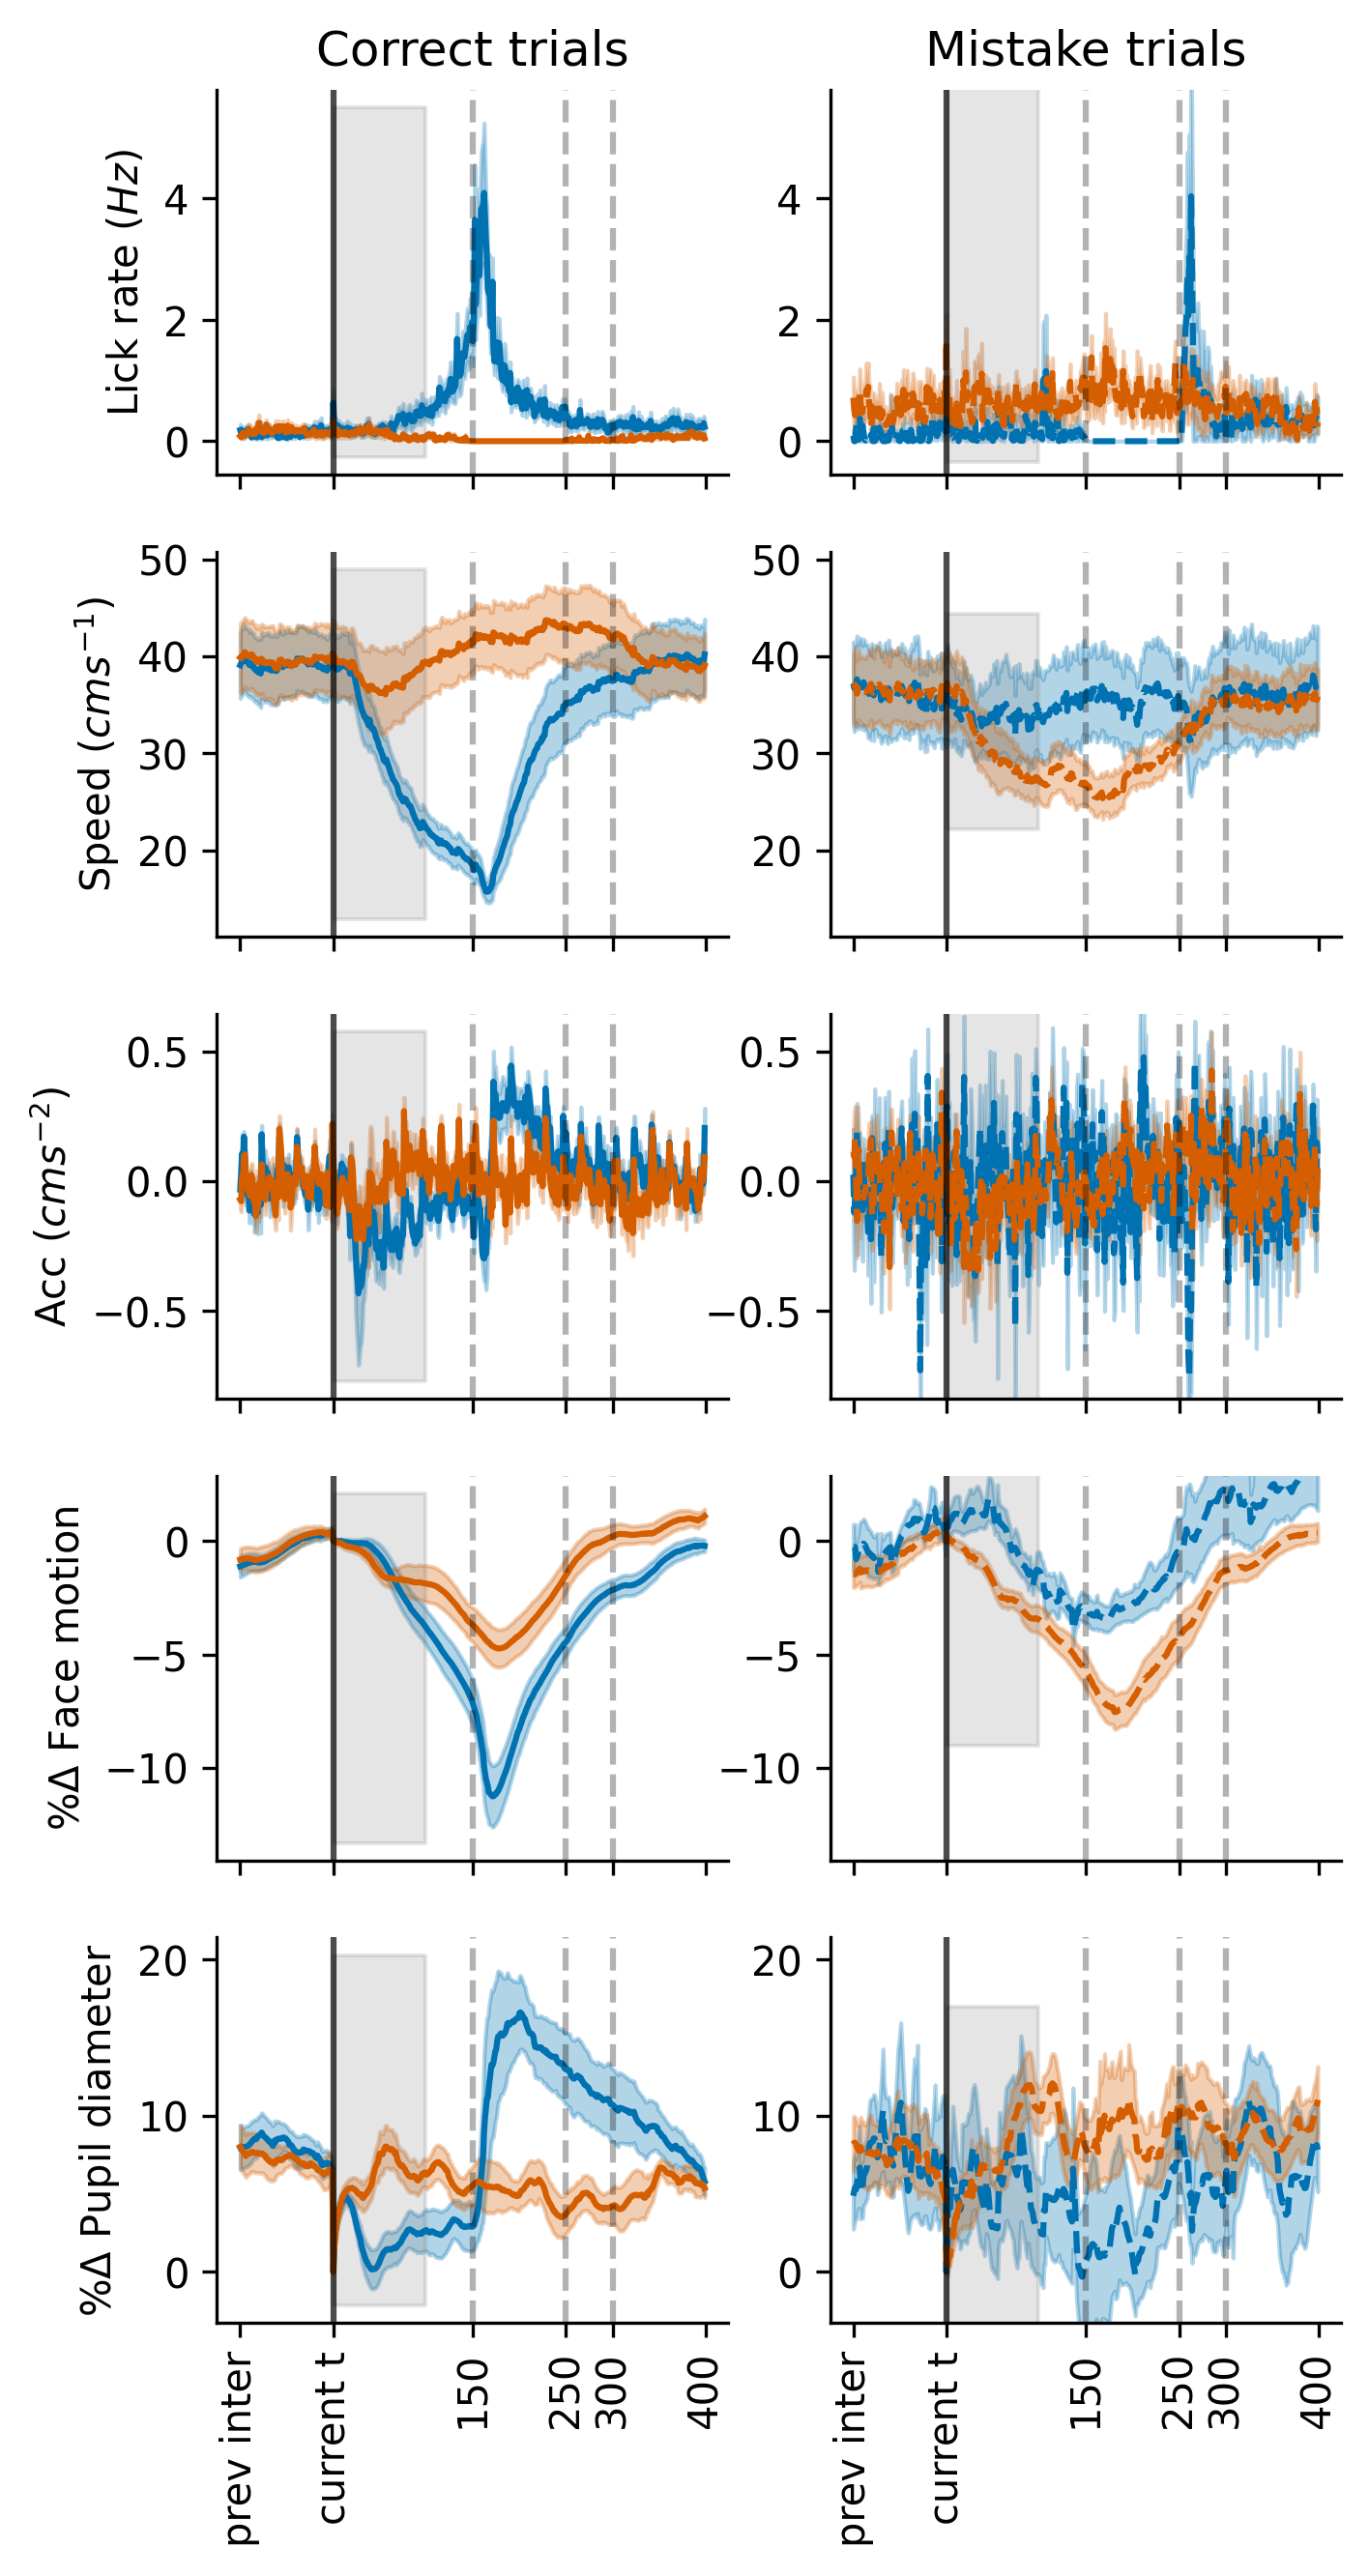

In [351]:
labels = [r"Lick rate ($Hz$)", r"Speed ($cms^{-1}$)", r"Acc ($cm s^{-2}$)", r"%$\Delta$ Face motion", r"%$\Delta$ Pupil diameter"]
fig, ax = plt.subplots(len(features), 2, figsize=(5, 10), sharex=True, dpi=300)
for i_f in range(len(features)):
    if i_f == len(features)-1:
        legend = True
    else:
        legend = False
    plot_catvsbehav(feature_means_mistakes[:,i_f, 0], feature_means_mistakes[:,i_f, 1], labels[i_f], False, ax[i_f, 0], legend=False)
    plot_catvsbehav(feature_means_mistakes[:,i_f, 0], feature_means_mistakes[:,i_f, 1], labels[i_f], False, ax[i_f, 1],  legend=False, onlymistake=True)
    #get y limits
    ymin, ymax = ax[i_f,0].get_ylim()
    ax[i_f,1].set_ylim(ymin, ymax)
    ax[i_f,1].set_ylabel("")
ax[0,0].set_title("Correct trials")
ax[0,1].set_title("Mistake trials")
sns.despine()

# task drift and procusters analysis

In [354]:
session_names = ['last training (matched)', 'all rewarded after']

In [352]:
working_dbase

,mname,datexp,blk,session,round_id,recording,obj
0,VG11,2024_10_15,4,all rewarded before,1,True,old
1,VG11,2024_10_16,2,first training,1,True,old
2,VG11,2024_10_31,2,last training,1,True,old
3,VG11,2024_11_01,2,all rewarded after,1,True,old
4,VG11,2024_11_04,2,all rewarded before,2,True,old
5,VG11,2024_11_05,3,first training,2,True,old
6,VG11,2024_11_14,2,last training,2,True,old
7,VG11,2024_11_15,2,all rewarded after,2,True,old
8,VG14,2024_10_15,2,all rewarded before,1,True,old
9,VG14,2024_10_16,2,first training,1,True,old


In [355]:
working_dbase.loc[:, "name_round"] = working_dbase["mname"] + "_"+ working_dbase["round_id"].astype(str)

In [364]:
last_analysis = working_dbase.query("session in ['last training', 'all rewarded after']").reset_index(drop=True)

In [365]:
last_analysis

,mname,datexp,blk,session,round_id,recording,obj,name_round
0,VG11,2024_10_31,2,last training,1,True,old,VG11_1
1,VG11,2024_11_01,2,all rewarded after,1,True,old,VG11_1
2,VG11,2024_11_14,2,last training,2,True,old,VG11_2
3,VG11,2024_11_15,2,all rewarded after,2,True,old,VG11_2
4,VG14,2024_11_21,2,last training,1,True,old,VG14_1
5,VG14,2024_11_23,2,all rewarded after,1,True,old,VG14_1
6,VG15,2024_10_31,2,last training,1,True,old,VG15_1
7,VG15,2024_11_01,3,all rewarded after,1,True,old,VG15_1
8,VG21,2025_07_17,3,last training,1,True,old,VG21_1
9,VG21,2025_07_18,2,all rewarded after,1,True,old,VG21_1


In [403]:
from scipy.spatial.distance import cosine
from src import rsm
rows = []
obj_path = Path(r"D:\mouseobj")
for i, (_, row) in enumerate(last_analysis.iterrows()):
    print(f"Processing {i+1} of {len(last_analysis)}")
    name, datexp, blk = row["mname"], row["datexp"], row["blk"]
    save_pth = obj_path.joinpath(name,datexp,blk)
    if row["session"] == "last training":
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        t_dict = get_matched_trials(m)
        means_all = m.interp_spks[:,:,:100].mean(2)
        means_all = means_all.T
        for area in areas:
            ia = utils.get_region_idx(m.iarea, area)
            for ic, cell in enumerate(celltype):
                sel_type = np.logical_not(m.isred[:, 0]).astype(bool) if cell == 'Pyr' else m.isred[:, 0].astype(bool)
                selection = ia * sel_type
                means_area_cell = means_all[:,selection]
                Rprot, NRprot, Rrest, NRrest = t_dict["rewarded"], t_dict["non rewarded"], t_dict["rewarded test"], t_dict["non rewarded test"]
                correct, incorrect = utils.build_correct_dicts(m)
                correct_protA = np.intersect1d(correct["rewarded"], Rprot)
                correct_protB = np.intersect1d(correct["non rewarded"], NRprot)
                w_task = means_area_cell[correct_protA].mean(0) - means_area_cell[correct_protB].mean(0)
                drift_vect_fa =  means_area_cell[incorrect['non rewarded test']].mean(0) - means_area_cell[correct['non rewarded test']].mean(0)
                drift_vect_miss =  means_area_cell[incorrect['rewarded test']].mean(0) - means_area_cell[correct['rewarded test']].mean(0)
                #drift from task 
                drift_fa = 1 - cosine(w_task, drift_vect_fa)
                drift_miss = 1 - cosine(w_task, drift_vect_miss)
                ### get rsm
                stim_mtx = rsm.get_istim_matrix(m, area=area, celltype=cell, cc_tsh=0.1)
                representation_matrix = rsm.get_rsm(stim_mtx)
                cat_A = np.nanmean(representation_matrix[:51, :51])
                cat_B = np.nanmean(representation_matrix[51:, 51:])
                within_avg = (cat_A + cat_B) / 2
                between_RU = np.nanmean(representation_matrix[:51, 51:])
                CSI_lastday = (between_RU - within_avg) / (within_avg + between_RU)
                rows.append({'name': name, 'datexp': datexp, 'blk': blk, 
                                'session': row["session"], 'celltype': cell, 'area': area, 
                                'drift_fa': drift_fa, 'drift_miss': drift_miss, 'csi': CSI_lastday})
    else:
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        for area in areas:
            for ic, cell in enumerate(celltype):
                stim_mtx = rsm.get_istim_matrix(m, area=area, celltype=cell, cc_tsh=0.1)
                representation_matrix = rsm.get_rsm(stim_mtx)
                cat_A = np.nanmean(representation_matrix[:51, :51])
                cat_B = np.nanmean(representation_matrix[51:, 51:])
                within_avg = (cat_A + cat_B) / 2
                between_RU = np.nanmean(representation_matrix[:51, 51:])
                CSI_allrew = (between_RU - within_avg) / (within_avg + between_RU)
                rows.append({'name': name, 'datexp': datexp, 'blk': blk, 
                                'session': row["session"], 'celltype': cell, 'area': area,
                                'drift_fa': pd.NA, 'drift_miss': pd.NA,'csi': CSI_allrew})
    clear_output(wait=True)
csi_drift_df = pd.DataFrame(rows)

Processing 19 of 19
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VGa9\2025_11_21\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
(4716, 102, 2)
(202, 102, 2)
(2287, 102, 2)
(101, 102, 2)
(1075, 102, 2)
(43, 102, 2)
(725, 102, 2)
(53, 102, 2)


In [404]:
csi_drift_df.to_csv(r"D:\mouseobj\overall\csi_drift_analysis.csv", index=False)

In [405]:
csi_drift_df

,name,datexp,blk,session,celltype,area,drift_fa,drift_miss,csi
0,VG11,2024_10_31,2,last training,Pyr,V1,0.109042,-0.194421,1.963564
1,VG11,2024_10_31,2,last training,Int,V1,0.358526,-0.458452,2.671504
2,VG11,2024_10_31,2,last training,Pyr,medial,0.26539,-0.34478,2.077938
3,VG11,2024_10_31,2,last training,Int,medial,0.402117,-0.369332,2.553732
4,VG11,2024_10_31,2,last training,Pyr,lateral,0.227021,-0.365117,1.946804
...,...,...,...,...,...,...,...,...,...
147,VGa9,2025_11_21,2,all rewarded after,Int,medial,<NA>,<NA>,13.651747
148,VGa9,2025_11_21,2,all rewarded after,Pyr,lateral,<NA>,<NA>,5.179036
149,VGa9,2025_11_21,2,all rewarded after,Int,lateral,<NA>,<NA>,5.472124
150,VGa9,2025_11_21,2,all rewarded after,Pyr,anterior,<NA>,<NA>,5.157808


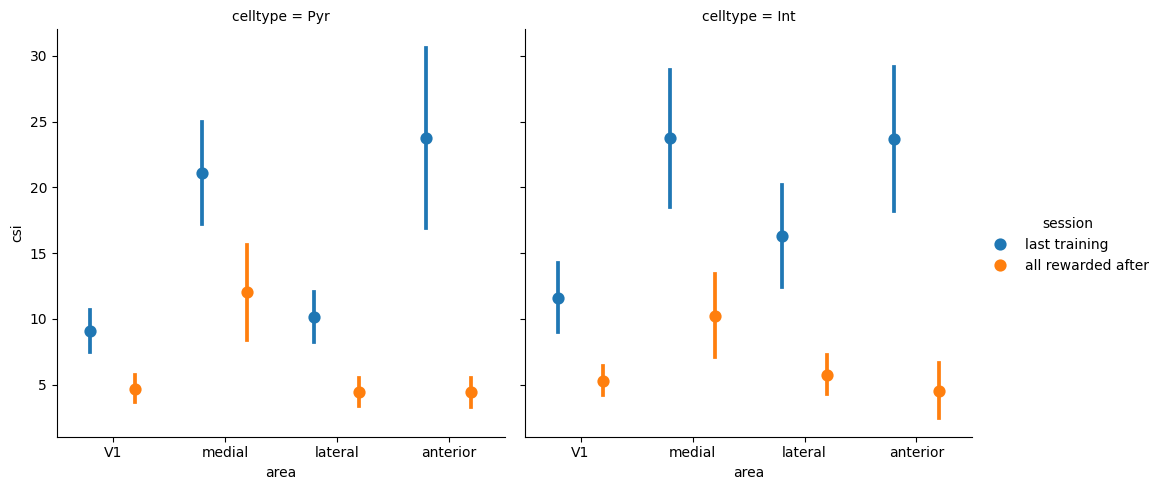

In [406]:
g = sns.catplot(data=csi_drift_df, x='area', y='csi', col='celltype', kind='point', width=4, aspect=1, dodge=.4, linestyle='none', hue='session', errorbar="se")

In [ ]:
g = sns.catplot(data=csi_drift_df, x='area', y='csi', col='celltype', kind='point', width=4, aspect=1, dodge=.4, linestyle='none', hue='session', errorbar="se")

,name,datexp,blk,session,celltype,area,drift_fa,drift_miss,csi
0,VG11,2024_10_31,2,last training,Pyr,V1,NaN,NaN,1.963564
1,VG11,2024_10_31,2,last training,Int,V1,NaN,NaN,2.671504
2,VG11,2024_10_31,2,last training,Pyr,medial,NaN,NaN,2.077938
3,VG11,2024_10_31,2,last training,Int,medial,NaN,NaN,2.553732
4,VG11,2024_10_31,2,last training,Pyr,lateral,NaN,NaN,1.946804
...,...,...,...,...,...,...,...,...,...
147,VGa9,2025_11_21,2,all rewarded after,Int,medial,NaN,NaN,13.651747
148,VGa9,2025_11_21,2,all rewarded after,Pyr,lateral,NaN,NaN,5.179036
149,VGa9,2025_11_21,2,all rewarded after,Int,lateral,NaN,NaN,5.472124
150,VGa9,2025_11_21,2,all rewarded after,Pyr,anterior,NaN,NaN,5.157808


In [408]:
drift_only_df = csi_drift_df.melt(id_vars=['name', 'datexp', 'blk', 'session', 'celltype', 'area'], value_vars=['drift_fa', 'drift_miss'], var_name='drift_type', value_name='drift_value')

In [409]:
drift_only_df = drift_only_df.query("session == 'last training'").reset_index(drop=True)

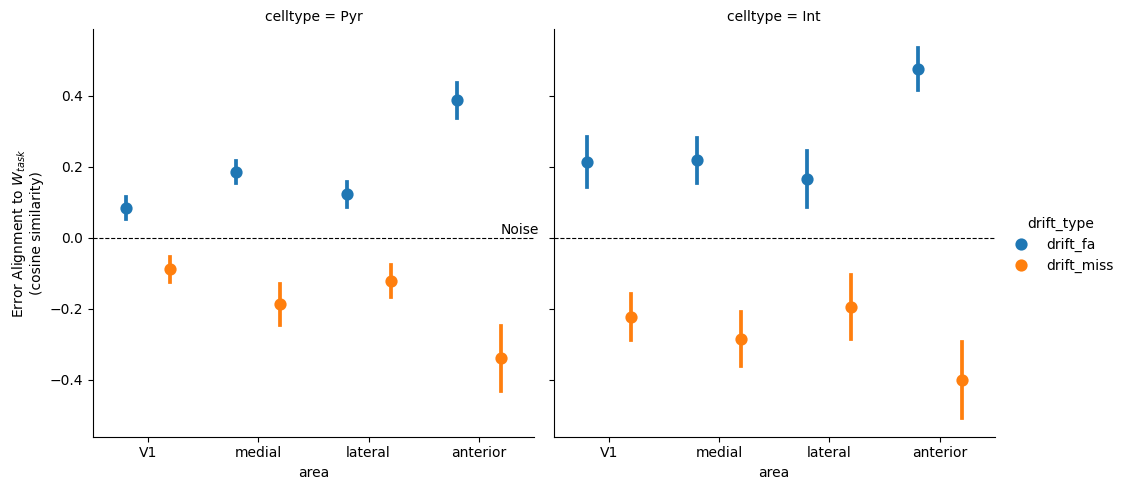

In [415]:
g = sns.catplot(data=drift_only_df, x='area', y='drift_value', col='celltype', kind='point', width=4, aspect=1, dodge=.4, linestyle='none', hue='drift_type', errorbar="se")
g.set_ylabels("Error Alignment to $W_{task}$ \n(cosine similarity)")
for iax, ax in enumerate(g.axes.flat):
    ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
    if iax == 0:
        ax.text(3.2, 0.001, 'Noise', transform=ax.transData, fontsize=10, verticalalignment='bottom')

In [379]:
area

'V1'

In [381]:
sel_type

array([ True,  True,  True, ...,  True,  True,  True], shape=(9284,))

In [393]:
name, datexp, blk = last_analysis.loc[0,'mname'], last_analysis.loc[0,'datexp'], last_analysis.loc[0,'blk']
m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
t_dict = get_matched_trials(m)
means_all = m.interp_spks[:,:,:100].mean(2)
means_all = means_all.T
for area in areas:
    ia = utils.get_region_idx(m.iarea, area)
    for ic, cell in enumerate(celltype):
        sel_type = np.logical_not(m.isred[:, 0]).astype(bool) if cell == 'Pyr' else m.isred[:, 0].astype(bool)
        selection = ia * sel_type
        means_area_cell = means_all[:,selection]
        Rprot, NRprot, Rrest, NRrest = t_dict["rewarded"], t_dict["non rewarded"], t_dict["rewarded test"], t_dict["non rewarded test"]
        correct, incorrect = utils.build_correct_dicts(m)
        correct_protA = np.intersect1d(correct["rewarded"], Rprot)
        correct_protB = np.intersect1d(correct["non rewarded"], NRprot)
        w_task = means_area_cell[correct_protA].mean(0) - means_area_cell[correct_protB].mean(0)
        drift_vect_fa =  means_area_cell[incorrect['non rewarded test']].mean(0) - means_area_cell[correct['non rewarded test']].mean(0)
        drift_vect_miss =  means_area_cell[incorrect['rewarded test']].mean(0) - means_area_cell[correct['rewarded test']].mean(0)
        #drift from task 
        drift_fa = 1 - cosine(w_task, drift_vect_fa)
        drift_miss = 1 - cosine(w_task, drift_vect_miss)

Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_10_31\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])


In [394]:
drift_fa, drift_miss

(np.float64(0.7481803892889769), np.float64(-0.7469684383745985))

In [395]:
csi_drift_df

,name,datexp,blk,session,celltype,area,drift_fa,drift_miss,csi
0,VG11,2024_10_31,2,last training,Pyr,V1,NaN,NaN,1.963564
1,VG11,2024_10_31,2,last training,Int,V1,NaN,NaN,2.671504
2,VG11,2024_10_31,2,last training,Pyr,medial,NaN,NaN,2.077938
3,VG11,2024_10_31,2,last training,Int,medial,NaN,NaN,2.553732
4,VG11,2024_10_31,2,last training,Pyr,lateral,NaN,NaN,1.946804
...,...,...,...,...,...,...,...,...,...
147,VGa9,2025_11_21,2,all rewarded after,Int,medial,NaN,NaN,13.651747
148,VGa9,2025_11_21,2,all rewarded after,Pyr,lateral,NaN,NaN,5.179036
149,VGa9,2025_11_21,2,all rewarded after,Int,lateral,NaN,NaN,5.472124
150,VGa9,2025_11_21,2,all rewarded after,Pyr,anterior,NaN,NaN,5.157808
